In [ ]:
# Option A : La plus simple et recommandée (Colab ou notebook local)
from huggingface_hub import login

# Méthode 1 : Coller ton token directement (attention : ne partage jamais le notebook !)
# Crée un token READ ici : https://huggingface.co/settings/tokens
# → New token → Read → Generate → copie-le
your_hf_token = ""   # Remplace par TON token

login(token=your_hf_token)
print("Login Hugging Face réussi ! Tu devrais maintenant pouvoir charger les modèles gated.")

Login Hugging Face réussi ! Tu devrais maintenant pouvoir charger les modèles gated.


In [ ]:
"""
Extraction d'activations — Gemma-3-270M + Dolly-15k
Corrections appliquées :
  - device_map="auto" supprimé → fix bug hidden_states à zéro (transformers #36636)
  - torch.inference_mode() au lieu de torch.no_grad() (plus rapide)
  - padding_side="right" explicite (Gemma utilise left par défaut, on force right pour cohérence avec le masque)
  - TARGET_LAYER variable explicite et paramétrable
  - Pré-allocation numpy (plus efficace mémoire)
  - try/except par prompt pour robustesse
  - Vérification défensive des activations nulles après le 1er batch
  - Simplification du masked mean pooling
  - float32 maintenu (bug NaN confirmé sur Gemma-3 en float16, voir transformers #39972)
"""

import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset

# ── Config ────────────────────────────────────────────────────────────────────
MODEL_ID    = "google/gemma-3-270m"
TARGET_LAYER = 8          # couche intermédiaire (0-indexé, hors embedding)
MAX_LENGTH   = 512
N_SAMPLES    = 2000
SAVE_PATH    = "gemma_270m_dolly_activations_masked.npy"

# ── Device ────────────────────────────────────────────────────────────────────
# NE PAS utiliser device_map="auto" avec output_hidden_states=True :
# bug confirmé (transformers #36636) → hidden_states à zéro sur couches déportées
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

# ── Tokenizer ─────────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Gemma utilise padding_side="left" par défaut ; on force "right" pour que
# le masked mean pooling soit cohérent (tokens réels en début de séquence)
tokenizer.padding_side = "right"

# ── Modèle ────────────────────────────────────────────────────────────────────
# float32 obligatoire : bug NaN confirmé sur Gemma-3 en float16 (transformers #39972)
# float32 obligatoire : bug NaN confirmé sur Gemma-3 en float16 (transformers #39972)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float32,
).to(device)
model.eval()

hidden_size    = model.config.hidden_size
num_layers     = model.config.num_hidden_layers
print(f"hidden_size : {hidden_size}  |  num_hidden_layers : {num_layers}")
assert TARGET_LAYER < num_layers, f"TARGET_LAYER={TARGET_LAYER} >= num_layers={num_layers}"

# ── Dataset ───────────────────────────────────────────────────────────────────
ds = load_dataset("databricks/databricks-dolly-15k", split=f"train[:{N_SAMPLES}]")
prompts = [
    ex["instruction"].strip() if len(ex["instruction"].strip()) > 20
    else "Describe a simple object."
    for ex in ds
]

# ── Extraction ────────────────────────────────────────────────────────────────
# Pré-allocation pour éviter les copies successives de listes Python
activations_array = np.zeros((len(prompts), hidden_size), dtype=np.float32)
skipped = []

for i, prompt in enumerate(prompts):
    if i % 200 == 0:
        print(f"  {i}/{len(prompts)}")

    try:
        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=MAX_LENGTH,
            return_attention_mask=True,
        ).to(device)

        # inference_mode désactive aussi le versioning des tenseurs intermédiaires
        with torch.inference_mode():
            outputs = model(**inputs, output_hidden_states=True)

        # hidden_states[0] = embedding, [1] = layer 0, ..., [N+1] = layer N
        hidden = outputs.hidden_states[TARGET_LAYER + 1]  # [1, 512, hidden_size]

        # Masked mean pooling simplifié
        mask   = inputs.attention_mask.float()             # [1, 512]
        pooled = (hidden * mask.unsqueeze(-1)).sum(1)      # [1, hidden_size]
        pooled = pooled / mask.sum(1, keepdim=True).clamp(min=1e-9)

        activations_array[i] = pooled.squeeze(0).cpu().numpy()

    except Exception as e:
        print(f"  ⚠️  Prompt {i} ignoré : {e}")
        skipped.append(i)
        # activations_array[i] reste à zéro (marqué comme skip)

    # Vérification défensive après le 1er prompt
    if i == 0 and np.allclose(activations_array[0], 0):
        raise RuntimeError(
            "BUG DÉTECTÉ : les activations du 1er prompt sont toutes à zéro.\n"
            "Probable bug device_map + hidden_states (transformers #36636).\n"
            "Vérifier la version de transformers ou forcer device manuel."
        )

# ── Résultats ─────────────────────────────────────────────────────────────────
print(f"\nShape finale  : {activations_array.shape}")
print(f"NaN count     : {np.isnan(activations_array).sum()}")
print(f"Prompts skippés : {len(skipped)} → indices {skipped[:10]}{'...' if len(skipped) > 10 else ''}")
print(f"Premier vecteur : {activations_array[0][:10]}")

np.save(SAVE_PATH, activations_array)
print(f"\n✅ Sauvegardé : {SAVE_PATH}")

Device : cuda


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

hidden_size : 640  |  num_hidden_layers : 18
  0/2000
  200/2000
  400/2000
  600/2000
  800/2000
  1000/2000
  1200/2000
  1400/2000
  1600/2000
  1800/2000

Shape finale  : (2000, 640)
NaN count     : 0
Prompts skippés : 0 → indices []
Premier vecteur : [ 30.94048      2.507643     0.31481287   1.5181129   -1.1475935
 -19.065       25.357887     2.3542492    1.8765631    2.2376072 ]

✅ Sauvegardé : gemma_270m_dolly_activations_masked.npy


In [ ]:
"""
Visualisations 2D & 3D des activations Gemma-3-270M
Charger d'abord : activations = np.load("gemma_270m_dolly_activations_masked.npy")
Shape attendue  : (2000, 640)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from umap import UMAP  # pip install umap-learn

activations = np.load("gemma_270m_dolly_activations_masked.npy")
print(f"Shape : {activations.shape}")  # (2000, 640)

# Normalisation standard (recommandée avant PCA/TSNE/UMAP)
scaler = StandardScaler()
X = scaler.fit_transform(activations)

# Couleurs par index (pour voir des clusters chronologiques éventuels)
colors = np.arange(len(X))


# ══════════════════════════════════════════════════════════════════════════════
# 2D — VIZ 1 : PCA 2D basique
# ══════════════════════════════════════════════════════════════════════════════
def viz_pca_2d(X, colors):
    pca = PCA(n_components=2)
    coords = pca.fit_transform(X)

    fig, ax = plt.subplots(figsize=(9, 7))
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=colors, cmap="viridis",
                    alpha=0.6, s=8)
    plt.colorbar(sc, ax=ax, label="Index prompt")
    ax.set_title(f"PCA 2D — variance expliquée : {pca.explained_variance_ratio_.sum():.1%}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    plt.tight_layout()
    plt.savefig("viz_pca_2d.png", dpi=150)
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 2D — VIZ 2 : t-SNE 2D
# ══════════════════════════════════════════════════════════════════════════════
def viz_tsne_2d(X, colors, perplexity=30):
    # PCA 50 dims d'abord pour accélérer t-SNE
    X_pca = PCA(n_components=50).fit_transform(X)
    tsne = TSNE(n_components=2, perplexity=perplexity, n_iter=1000,
                random_state=42, verbose=1)
    coords = tsne.fit_transform(X_pca)

    fig, ax = plt.subplots(figsize=(9, 7))
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=colors, cmap="plasma",
                    alpha=0.6, s=8)
    plt.colorbar(sc, ax=ax, label="Index prompt")
    ax.set_title(f"t-SNE 2D (perplexity={perplexity})")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    plt.tight_layout()
    plt.savefig("viz_tsne_2d.png", dpi=150)
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 2D — VIZ 3 : UMAP 2D
# ══════════════════════════════════════════════════════════════════════════════
def viz_umap_2d(X, colors, n_neighbors=15, min_dist=0.1):
    reducer = UMAP(n_components=2, n_neighbors=n_neighbors,
                   min_dist=min_dist, random_state=42)
    coords = reducer.fit_transform(X)

    fig, ax = plt.subplots(figsize=(9, 7))
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=colors, cmap="coolwarm",
                    alpha=0.6, s=8)
    plt.colorbar(sc, ax=ax, label="Index prompt")
    ax.set_title(f"UMAP 2D (n_neighbors={n_neighbors}, min_dist={min_dist})")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    plt.tight_layout()
    plt.savefig("viz_umap_2d.png", dpi=150)
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 2D — VIZ 4 : Heatmap des activations brutes (sous-échantillon)
# ══════════════════════════════════════════════════════════════════════════════
def viz_heatmap(activations, n=200):
    """Affiche les n premiers prompts × toutes les dimensions."""
    subset = activations[:n]

    fig, ax = plt.subplots(figsize=(14, 6))
    im = ax.imshow(subset.T, aspect="auto", cmap="RdBu_r",
                   vmin=np.percentile(subset, 2),
                   vmax=np.percentile(subset, 98))
    plt.colorbar(im, ax=ax, label="Activation")
    ax.set_title(f"Heatmap activations — {n} prompts × {subset.shape[1]} dims")
    ax.set_xlabel("Index prompt")
    ax.set_ylabel("Dimension cachée")
    plt.tight_layout()
    plt.savefig("viz_heatmap.png", dpi=150)
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 2D — VIZ 5 : Variance par dimension (quelles features bougent le plus)
# ══════════════════════════════════════════════════════════════════════════════
def viz_variance_par_dim(activations):
    variances = activations.var(axis=0)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(variances, linewidth=0.8, color="steelblue")
    ax.fill_between(range(len(variances)), variances, alpha=0.3, color="steelblue")
    ax.set_title("Variance par dimension cachée")
    ax.set_xlabel("Dimension (0 → 639)")
    ax.set_ylabel("Variance")
    plt.tight_layout()
    plt.savefig("viz_variance.png", dpi=150)
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 2D — VIZ 6 : Scree plot PCA (variance cumulée)
# ══════════════════════════════════════════════════════════════════════════════
def viz_scree_pca(X, n_components=50):
    pca = PCA(n_components=n_components)
    pca.fit(X)
    cumvar = np.cumsum(pca.explained_variance_ratio_)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(range(1, n_components + 1), pca.explained_variance_ratio_,
                color="steelblue")
    axes[0].set_title("Variance expliquée par composante")
    axes[0].set_xlabel("Composante")
    axes[0].set_ylabel("Ratio")

    axes[1].plot(range(1, n_components + 1), cumvar, marker="o", ms=4,
                 color="darkorange")
    axes[1].axhline(0.9, color="red", linestyle="--", label="90%")
    axes[1].set_title("Variance cumulée PCA")
    axes[1].set_xlabel("Nb composantes")
    axes[1].set_ylabel("Variance cumulée")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("viz_scree.png", dpi=150)
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 2D — VIZ 7 : Matrice de corrélation inter-dimensions (sous-espace PCA)
# ══════════════════════════════════════════════════════════════════════════════
def viz_corr_matrix(X, n_components=20):
    X_pca = PCA(n_components=n_components).fit_transform(X)
    corr = np.corrcoef(X_pca.T)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, label="Corrélation")
    ax.set_title(f"Corrélation entre les {n_components} premières composantes PCA")
    ax.set_xticks(range(n_components))
    ax.set_yticks(range(n_components))
    plt.tight_layout()
    plt.savefig("viz_corr.png", dpi=150)
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 3D — VIZ 8 : PCA 3D interactif (matplotlib)
# ══════════════════════════════════════════════════════════════════════════════
def viz_pca_3d(X, colors):
    from mpl_toolkits.mplot3d import Axes3D  # noqa

    pca = PCA(n_components=3)
    coords = pca.fit_transform(X)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                    c=colors, cmap="viridis", alpha=0.5, s=6)
    plt.colorbar(sc, ax=ax, label="Index prompt", shrink=0.6)
    ax.set_title(f"PCA 3D — variance : {pca.explained_variance_ratio_.sum():.1%}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    plt.tight_layout()
    plt.savefig("viz_pca_3d.png", dpi=150)
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 3D — VIZ 9 : t-SNE 3D
# ══════════════════════════════════════════════════════════════════════════════
def viz_tsne_3d(X, colors, perplexity=30):
    from mpl_toolkits.mplot3d import Axes3D  # noqa

    X_pca = PCA(n_components=50).fit_transform(X)
    coords = TSNE(n_components=3, perplexity=perplexity,
                  random_state=42, verbose=1).fit_transform(X_pca)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                    c=colors, cmap="plasma", alpha=0.5, s=6)
    plt.colorbar(sc, ax=ax, label="Index prompt", shrink=0.6)
    ax.set_title(f"t-SNE 3D (perplexity={perplexity})")
    plt.tight_layout()
    plt.savefig("viz_tsne_3d.png", dpi=150)
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 3D — VIZ 10 : UMAP 3D
# ══════════════════════════════════════════════════════════════════════════════
def viz_umap_3d(X, colors, n_neighbors=15, min_dist=0.1):
    from mpl_toolkits.mplot3d import Axes3D  # noqa

    coords = UMAP(n_components=3, n_neighbors=n_neighbors,
                  min_dist=min_dist, random_state=42).fit_transform(X)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                    c=colors, cmap="coolwarm", alpha=0.5, s=6)
    plt.colorbar(sc, ax=ax, label="Index prompt", shrink=0.6)
    ax.set_title(f"UMAP 3D (n_neighbors={n_neighbors})")
    plt.tight_layout()
    plt.savefig("viz_umap_3d.png", dpi=150)
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 3D — VIZ 11 : Surface PCA — densité dans l'espace latent (kernel density)
# ══════════════════════════════════════════════════════════════════════════════
def viz_density_surface_3d(X):
    from mpl_toolkits.mplot3d import Axes3D  # noqa
    from scipy.stats import gaussian_kde

    pca = PCA(n_components=2)
    coords = pca.fit_transform(X)

    x, y = coords[:, 0], coords[:, 1]
    kde = gaussian_kde(np.vstack([x, y]))

    xi = np.linspace(x.min(), x.max(), 80)
    yi = np.linspace(y.min(), y.max(), 80)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)

    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(Xi, Yi, Zi, cmap="inferno", alpha=0.85, edgecolor="none")
    ax.set_title("Surface de densité KDE dans l'espace PCA 2D")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("Densité")
    plt.tight_layout()
    plt.savefig("viz_density_surface.png", dpi=150)
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 3D — VIZ 12 : Plotly interactif 3D (UMAP) — le plus utile en pratique
# ══════════════════════════════════════════════════════════════════════════════
def viz_plotly_umap_3d(X, colors, n_neighbors=15, min_dist=0.1):
    """
    Nécessite : pip install plotly
    Produit un fichier HTML interactif (rotation, zoom, hover).
    """
    import plotly.graph_objects as go

    coords = UMAP(n_components=3, n_neighbors=n_neighbors,
                  min_dist=min_dist, random_state=42).fit_transform(X)

    fig = go.Figure(data=[go.Scatter3d(
        x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
        mode="markers",
        marker=dict(
            size=3,
            color=colors,
            colorscale="Viridis",
            opacity=0.7,
            colorbar=dict(title="Index prompt"),
        ),
        text=[f"Prompt #{i}" for i in range(len(coords))],
        hovertemplate="<b>%{text}</b><br>x=%{x:.2f} y=%{y:.2f} z=%{z:.2f}<extra></extra>",
    )])

    fig.update_layout(
        title="UMAP 3D interactif — Activations Gemma-3-270M",
        scene=dict(xaxis_title="UMAP 1", yaxis_title="UMAP 2", zaxis_title="UMAP 3"),
        margin=dict(l=0, r=0, b=0, t=40),
    )

    fig.write_html("viz_umap_3d_interactif.html")
    fig.show()
    print("✅ Sauvegardé : viz_umap_3d_interactif.html")


# ══════════════════════════════════════════════════════════════════════════════
# MAIN — commenter/décommenter les vues voulues
# ══════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":

    # ── 2D ──────────────────────────────────────────────────────────────────
    viz_pca_2d(X, colors)               # Viz 1 : PCA 2D
    viz_tsne_2d(X, colors)              # Viz 2 : t-SNE 2D  (lent ~1-2 min)
    viz_umap_2d(X, colors)              # Viz 3 : UMAP 2D
    viz_heatmap(activations)            # Viz 4 : heatmap brute
    viz_variance_par_dim(activations)   # Viz 5 : variance par dim
    viz_scree_pca(X)                    # Viz 6 : scree plot PCA
    viz_corr_matrix(X)                  # Viz 7 : matrice de corrélation

    # ── 3D ──────────────────────────────────────────────────────────────────
    viz_pca_3d(X, colors)               # Viz 8  : PCA 3D
    viz_tsne_3d(X, colors)              # Viz 9  : t-SNE 3D (lent)
    viz_umap_3d(X, colors)              # Viz 10 : UMAP 3D
    viz_density_surface_3d(X)           # Viz 11 : surface densité KDE
    viz_plotly_umap_3d(X, colors)       # Viz 12 : UMAP 3D interactif HTML ⭐

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
"""
Sonification sinusoïdale — Numpy complet (2000 prompts × 640 dims)
──────────────────────────────────────────────────────────────────
Mapping :
  • Chaque prompt    → segment audio de NOTE_DUR secondes
  • Chaque dimension → sinusoïde à fréquence fixe (log-spaced)
  • Amplitude        → |activation| normalisée
  • Phase            → 0 si positif, π si négatif
  • Fade in/out      → FADE secondes (évite les clics)

Config recommandée selon usage :
  • Exploration rapide  : NOTE_DUR=0.1, N_DIMS=64
  • Écoute complète     : NOTE_DUR=0.3, N_DIMS=128
  • Haute fidélité      : NOTE_DUR=0.5, N_DIMS=640 (lent, ~25 min de rendu)

Sortie : activations_full_sonification.wav
"""

import numpy as np
from scipy.io import wavfile
import time

# ── Config ─────────────────────────────────────────────────────────────────────
INPUT_NPY   = "gemma_270m_dolly_activations_masked.npy"
OUTPUT_WAV  = "activations_full_sonification.wav"

SR          = 44100     # sample rate Hz
NOTE_DUR    = 0.3       # secondes par prompt  ← ajuster selon usage
FADE        = 0.02      # fade in/out en secondes (évite les clics)
N_DIMS      = 128       # nombre de dimensions encodées (max 640)
                        # plus élevé = plus riche mais plus lent à calculer
F_MIN       = 60.0      # fréquence la plus grave (Hz)
F_MAX       = 4000.0    # fréquence la plus aiguë (Hz)
BATCH_SIZE  = 50        # prompts traités à la fois (gestion mémoire)

# ── Chargement ─────────────────────────────────────────────────────────────────
print(f"Chargement : {INPUT_NPY}")
activations = np.load(INPUT_NPY)
N_PROMPTS, TOTAL_DIMS = activations.shape
N_DIMS = min(N_DIMS, TOTAL_DIMS)

print(f"Shape       : {activations.shape}")
print(f"Dimensions  : {N_DIMS}/{TOTAL_DIMS} utilisées")
print(f"Durée audio : {N_PROMPTS * NOTE_DUR:.1f}s = {N_PROMPTS * NOTE_DUR / 60:.1f} min")
print(f"Taille WAV  : ~{N_PROMPTS * NOTE_DUR * SR * 2 / 1e6:.1f} MB")
print()

# ── Sous-ensemble des dimensions ───────────────────────────────────────────────
# On sélectionne les N_DIMS dimensions avec la plus grande variance
# → les plus "informatives" plutôt qu'un simple slice [:N_DIMS]
variances   = activations.var(axis=0)
top_dims    = np.argsort(variances)[-N_DIMS:][::-1]   # tri décroissant
extrait     = activations[:, top_dims]                 # (N_PROMPTS, N_DIMS)

print(f"Top {N_DIMS} dimensions sélectionnées par variance")
print(f"Variance min sélectionnée : {variances[top_dims[-1]]:.2f}")
print(f"Variance max sélectionnée : {variances[top_dims[0]]:.2f}")
print()

# ── Fréquences & normalisation ─────────────────────────────────────────────────
# Fréquences log-espacées : chaque dimension a sa "couleur" sonore fixe
freqs = np.exp(np.linspace(np.log(F_MIN), np.log(F_MAX), N_DIMS))

# Normalisation globale des amplitudes sur tout le dataset
abs_max = np.abs(extrait).max()

# ── Enveloppe fade in/out ──────────────────────────────────────────────────────
samples_per_note = int(SR * NOTE_DUR)
fade_samples     = int(SR * FADE)
envelope         = np.ones(samples_per_note)
envelope[:fade_samples]  = np.linspace(0, 1, fade_samples)
envelope[-fade_samples:] = np.linspace(1, 0, fade_samples)

# ── Vecteur de temps pour une note ────────────────────────────────────────────
t_note = np.linspace(0, NOTE_DUR, samples_per_note, endpoint=False)

# Pré-calcul des matrices de sinusoïdes (N_DIMS × samples_per_note)
# base_sines[d, :] = sin(2π * freqs[d] * t)   → on modulera amplitude et phase
print("Pré-calcul des sinusoïdes de base...")
base_sines = np.sin(2 * np.pi * freqs[:, None] * t_note[None, :])  # (N_DIMS, samples)
print("Pré-calcul terminé.\n")

# ── Génération du signal par batch ─────────────────────────────────────────────
total_samples = N_PROMPTS * samples_per_note
signal        = np.zeros(total_samples, dtype=np.float32)

print(f"Génération du signal ({N_PROMPTS} prompts)...")
t0 = time.time()

for batch_start in range(0, N_PROMPTS, BATCH_SIZE):
    batch_end = min(batch_start + BATCH_SIZE, N_PROMPTS)
    batch     = extrait[batch_start:batch_end]          # (batch, N_DIMS)

    # Amplitudes : valeurs absolues normalisées → (batch, N_DIMS)
    amplitudes = np.abs(batch) / (abs_max + 1e-9)

    # Phases : 0 ou π selon le signe → (batch, N_DIMS)
    phases = np.where(batch >= 0, 0.0, np.pi)

    for i, (amps, phs) in enumerate(zip(amplitudes, phases)):
        prompt_idx = batch_start + i

        # Modulation : amp × sin(base + phase)
        # amps : (N_DIMS,)  phs : (N_DIMS,)  base_sines : (N_DIMS, samples)
        weighted = amps[:, None] * np.cos(phs[:, None]) * base_sines  # phase shift via cos
        # Équivalent à amp * sin(wt + φ) via identité sin(a+b)
        # Simplification directe :
        weighted = (amps[:, None] * np.sin(
            2 * np.pi * freqs[:, None] * t_note[None, :] + phs[:, None]
        ))                                              # (N_DIMS, samples)

        note = weighted.sum(axis=0)                    # (samples,)

        # Normalisation par note + enveloppe
        peak = np.abs(note).max()
        if peak > 1e-9:
            note = note / peak
        note *= envelope

        start = prompt_idx * samples_per_note
        signal[start:start + samples_per_note] = note.astype(np.float32)

    # Progress
    elapsed   = time.time() - t0
    progress  = batch_end / N_PROMPTS
    remaining = elapsed / progress * (1 - progress) if progress > 0 else 0
    print(f"  [{batch_end:4d}/{N_PROMPTS}] {progress*100:5.1f}% — "
          f"écoulé: {elapsed:.0f}s — restant estimé: {remaining:.0f}s")

print(f"\nGénération terminée en {time.time()-t0:.1f}s")

# ── Normalisation finale → int16 ───────────────────────────────────────────────
print("Normalisation finale...")
peak = np.abs(signal).max()
if peak > 1e-9:
    signal /= peak
signal_int16 = (signal * 32000).astype(np.int16)

# ── Sauvegarde ─────────────────────────────────────────────────────────────────
print(f"Sauvegarde : {OUTPUT_WAV}")
wavfile.write(OUTPUT_WAV, SR, signal_int16)

size_mb = signal_int16.nbytes / 1e6
print(f"\n✅ Terminé !")
print(f"   Fichier : {OUTPUT_WAV}")
print(f"   Durée   : {len(signal_int16)/SR:.1f}s ({len(signal_int16)/SR/60:.1f} min)")
print(f"   Taille  : {size_mb:.1f} MB")
print(f"   Config  : {N_PROMPTS} prompts × {NOTE_DUR}s | {N_DIMS} dims | {SR}Hz")

Chargement : gemma_270m_dolly_activations_masked.npy
Shape       : (2000, 640)
Dimensions  : 128/640 utilisées
Durée audio : 600.0s = 10.0 min
Taille WAV  : ~52.9 MB

Top 128 dimensions sélectionnées par variance
Variance min sélectionnée : 187.52
Variance max sélectionnée : 11444689.00

Pré-calcul des sinusoïdes de base...
Pré-calcul terminé.

Génération du signal (2000 prompts)...
  [  50/2000]   2.5% — écoulé: 5s — restant estimé: 206s
  [ 100/2000]   5.0% — écoulé: 8s — restant estimé: 154s
  [ 150/2000]   7.5% — écoulé: 11s — restant estimé: 135s
  [ 200/2000]  10.0% — écoulé: 14s — restant estimé: 123s
  [ 250/2000]  12.5% — écoulé: 17s — restant estimé: 117s
  [ 300/2000]  15.0% — écoulé: 18s — restant estimé: 104s
  [ 350/2000]  17.5% — écoulé: 20s — restant estimé: 94s
  [ 400/2000]  20.0% — écoulé: 21s — restant estimé: 86s
  [ 450/2000]  22.5% — écoulé: 23s — restant estimé: 79s
  [ 500/2000]  25.0% — écoulé: 25s — restant estimé: 74s
  [ 550/2000]  27.5% — écoulé: 26s — res

Chargement du modèle...


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

Prompt : "
They fuck you up, your mum and dad.   
    They may not mean to, but they do.   
They fill you with the faults they had
    And add some extra, just for you.

But they were fucked up in their turn
    By fools in old-style hats and coats,   
Who half the time were soppy-stern
    And half at one another’s throats.

Man hands on misery to man.
    It deepens like a coastal shelf.
Get out as early as you can,
    And don’t have any kids yourself.
    "
Tokens (129) : ['<bos>', '\n', 'They', '▁fuck', '▁you', '▁up', ',', '▁your', '▁mum', '▁and', '▁dad', '.', '▁▁▁', '\n', '▁▁▁▁', 'They', '▁may', '▁not', '▁mean', '▁to', ',', '▁but', '▁they', '▁do', '.', '▁▁▁', '\n', 'They', '▁fill', '▁you', '▁with', '▁the', '▁faults', '▁they', '▁had', '\n', '▁▁▁▁', 'And', '▁add', '▁some', '▁extra', ',', '▁just', '▁for', '▁you', '.', '\n\n', 'But', '▁they', '▁were', '▁fucked', '▁up', '▁in', '▁their', '▁turn', '\n', '▁▁▁▁', 'By', '▁fools', '▁in', '▁old', '-', 'style', '▁hats', '▁and', '▁coats', ',',

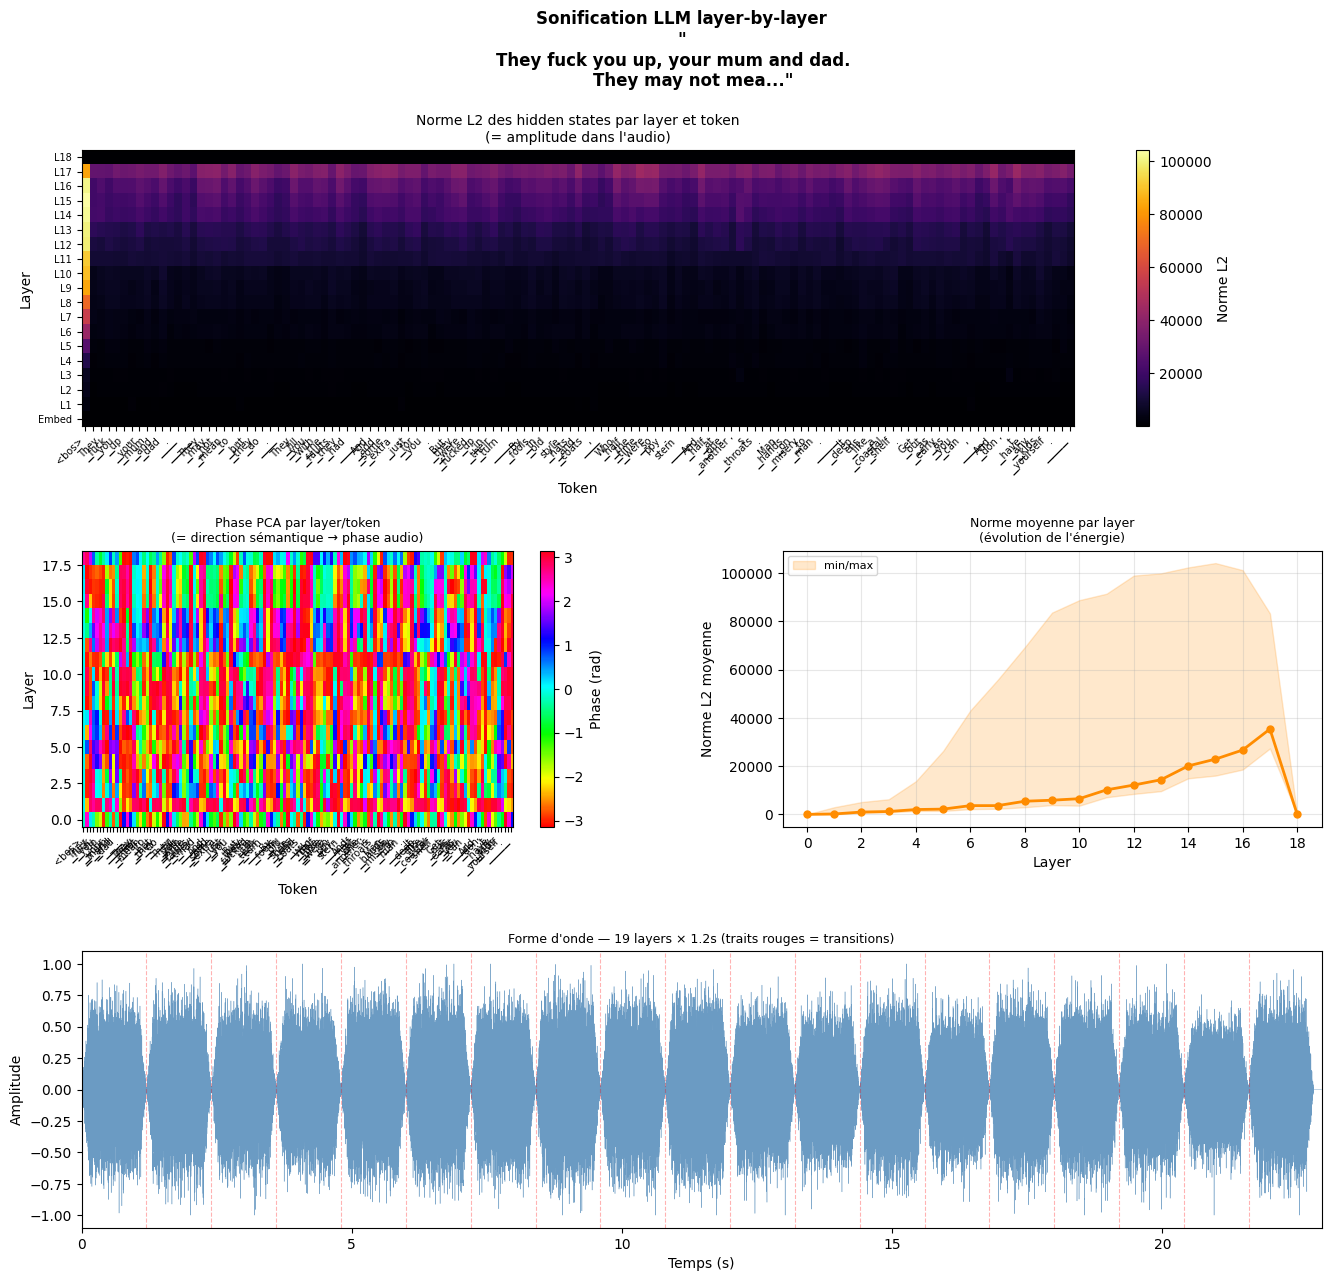

✅ Visualisation : llm_thinking_viz.png

🎵 Mapping final :
   Token position → Fréquence  (80Hz grave → 5000Hz aigu)
   Norme L2       → Amplitude  (token 'fort' = plus loud)
   Angle PCA      → Phase      (direction sémantique = timbre)
   Layer          → Temps      (1.2s par layer, crossfade 0.15s)


In [ ]:
"""
Sonification de la pensée d'un LLM — Layer par Layer
══════════════════════════════════════════════════════
Capture tous les hidden states d'un seul prompt à travers tous les layers,
et les encode en audio sinusoïdal.

Structure :  (n_layers+1, n_tokens, hidden_size)
              └ embedding + 18 layers pour Gemma-3-270M

Mapping temporel :
  • Chaque layer    → segment audio de LAYER_DUR secondes
  • Chaque token    → sinusoïde à fréquence dédiée (log-spaced)
  • Amplitude       → norme L2 du vecteur caché de ce token à ce layer
  • Phase           → angle dans l'espace PCA 2D (direction sémantique)
  • Fade            → crossfade entre layers pour fluidité

Résultat : on "entend" comment le modèle transforme la représentation
du prompt couche après couche — grave=premiers tokens, aigu=derniers tokens.
"""

import torch
import numpy as np
from scipy.io import wavfile
from scipy.signal import butter, sosfilt
from sklearn.decomposition import PCA
from transformers import AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Config ─────────────────────────────────────────────────────────────────────
MODEL_ID   = "google/gemma-3-270m"
PROMPT     = "The nature of consciousness remains one of the deepest mysteries in philosophy and science."

SR         = 44100      # sample rate Hz
LAYER_DUR  = 1.2        # secondes par layer
FADE       = 0.15       # crossfade entre layers (secondes)
F_MIN      = 80.0       # fréquence grave (Hz) — premier token
F_MAX      = 5000.0     # fréquence aiguë (Hz) — dernier token
OUTPUT_WAV = "llm_thinking_sonification.wav"
OUTPUT_PNG = "llm_thinking_viz.png"

# ── 1. Extraction des hidden states ───────────────────────────────────────────
print("Chargement du modèle...")
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.float32
).to(device)
model.eval()

print(f"Prompt : \"{PROMPT}\"")
inputs  = tokenizer(PROMPT, return_tensors="pt").to(device)
tokens  = tokenizer.convert_ids_to_tokens(inputs.input_ids[0])
N_TOKENS = len(tokens)
print(f"Tokens ({N_TOKENS}) : {tokens}")

with torch.inference_mode():
    outputs = model(**inputs, output_hidden_states=True)

# Stack : (n_layers+1, n_tokens, hidden_size)
all_hs = np.stack([
    hs.squeeze(0).cpu().numpy()
    for hs in outputs.hidden_states
])
N_LAYERS, N_TOKENS, HIDDEN = all_hs.shape
print(f"\nShape hidden states : {all_hs.shape}")
print(f"  {N_LAYERS} layers × {N_TOKENS} tokens × {HIDDEN} dims")

# ── 2. Mapping vers paramètres sonores ────────────────────────────────────────
# Fréquence par token (log-spaced, grave→aigu = premier→dernier token)
freqs = np.exp(np.linspace(np.log(F_MIN), np.log(F_MAX), N_TOKENS))

# Amplitude par (layer, token) = norme L2 normalisée
norms = np.linalg.norm(all_hs, axis=-1)          # (N_LAYERS, N_TOKENS)
norms_norm = norms / (norms.max() + 1e-9)

# Phase par (layer, token) = angle dans l'espace PCA 2D du layer
# Donne une "direction sémantique" à chaque token à chaque layer
pca = PCA(n_components=2)
phases = np.zeros((N_LAYERS, N_TOKENS))
for l in range(N_LAYERS):
    try:
        coords = pca.fit_transform(all_hs[l])      # (N_TOKENS, 2)
        angles = np.arctan2(coords[:, 1], coords[:, 0])  # (N_TOKENS,)
        phases[l] = angles
    except Exception:
        phases[l] = 0.0

# ── 3. Génération audio ────────────────────────────────────────────────────────
samples_per_layer = int(SR * LAYER_DUR)
fade_samples      = int(SR * FADE)
t_layer           = np.linspace(0, LAYER_DUR, samples_per_layer, endpoint=False)

# Enveloppe fade in/out
envelope = np.ones(samples_per_layer)
envelope[:fade_samples]  = np.linspace(0, 1, fade_samples)
envelope[-fade_samples:] = np.linspace(1, 0, fade_samples)

# Signal avec overlap-add pour crossfade entre layers
total_samples = samples_per_layer * N_LAYERS + fade_samples
signal        = np.zeros(total_samples, dtype=np.float64)

print("\nGénération du signal audio...")
for l in range(N_LAYERS):
    note = np.zeros(samples_per_layer)

    for tok in range(N_TOKENS):
        amp   = norms_norm[l, tok]
        phase = phases[l, tok]
        freq  = freqs[tok]
        sine  = amp * np.sin(2 * np.pi * freq * t_layer + phase)
        note += sine

    # Normalisation + enveloppe
    peak = np.abs(note).max()
    if peak > 1e-9:
        note /= peak
    note *= envelope

    # Overlap-add : chaque layer commence FADE secondes avant la fin du précédent
    start = l * samples_per_layer
    signal[start:start + samples_per_layer] += note

    layer_name = "Embedding" if l == 0 else f"Layer {l}"
    print(f"  {layer_name:12s} — norme moy: {norms[l].mean():.2f}  "
          f"phase moy: {phases[l].mean():.2f} rad")

# Normalisation finale
signal = signal / (np.abs(signal).max() + 1e-9)
signal_int16 = (signal * 32000).astype(np.int16)

wavfile.write(OUTPUT_WAV, SR, signal_int16)
print(f"\n✅ Audio : {OUTPUT_WAV}  ({len(signal_int16)/SR:.1f}s, {SR}Hz)")

# ── 4. Visualisation ──────────────────────────────────────────────────────────
print("Génération de la visualisation...")

fig = plt.figure(figsize=(16, 14))
fig.suptitle(
    f'Sonification LLM layer-by-layer\n"{PROMPT[:60]}..."',
    fontsize=12, fontweight='bold'
)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# Panel 1 : Heatmap des normes (layers × tokens)
ax1 = fig.add_subplot(gs[0, :])
im = ax1.imshow(norms, aspect='auto', cmap='inferno', origin='lower')
plt.colorbar(im, ax=ax1, label='Norme L2')
ax1.set_title("Norme L2 des hidden states par layer et token\n(= amplitude dans l'audio)", fontsize=10)
ax1.set_xlabel("Token"); ax1.set_ylabel("Layer")
ax1.set_xticks(range(N_TOKENS))
ax1.set_xticklabels(tokens, rotation=45, ha='right', fontsize=7)
ax1.set_yticks(range(N_LAYERS))
ax1.set_yticklabels(
    ["Embed"] + [f"L{i}" for i in range(1, N_LAYERS)], fontsize=7
)

# Panel 2 : Heatmap des phases
ax2 = fig.add_subplot(gs[1, 0])
im2 = ax2.imshow(phases, aspect='auto', cmap='hsv', origin='lower',
                 vmin=-np.pi, vmax=np.pi)
plt.colorbar(im2, ax=ax2, label='Phase (rad)')
ax2.set_title("Phase PCA par layer/token\n(= direction sémantique → phase audio)", fontsize=9)
ax2.set_xlabel("Token"); ax2.set_ylabel("Layer")
ax2.set_xticks(range(N_TOKENS))
ax2.set_xticklabels(tokens, rotation=45, ha='right', fontsize=7)

# Panel 3 : Evolution de la norme moyenne par layer
ax3 = fig.add_subplot(gs[1, 1])
mean_norms = norms.mean(axis=1)
ax3.plot(mean_norms, 'o-', color='darkorange', linewidth=2, markersize=5)
ax3.fill_between(range(N_LAYERS), norms.min(axis=1), norms.max(axis=1),
                 alpha=0.2, color='darkorange', label='min/max')
ax3.set_title("Norme moyenne par layer\n(évolution de l'énergie)", fontsize=9)
ax3.set_xlabel("Layer"); ax3.set_ylabel("Norme L2 moyenne")
ax3.set_xticks(range(0, N_LAYERS, 2))
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

# Panel 4 : Waveform audio
ax4 = fig.add_subplot(gs[2, :])
t_audio = np.linspace(0, len(signal_int16)/SR, len(signal_int16))
ax4.plot(t_audio, signal_int16.astype(np.float32)/32000,
         linewidth=0.3, color='steelblue', alpha=0.8)
for l in range(1, N_LAYERS):
    ax4.axvline(x=l * LAYER_DUR, color='red', alpha=0.3,
                linestyle='--', linewidth=0.8)
ax4.set_title(f"Forme d'onde — {N_LAYERS} layers × {LAYER_DUR}s (traits rouges = transitions)", fontsize=9)
ax4.set_xlabel("Temps (s)"); ax4.set_ylabel("Amplitude")
ax4.set_xlim(0, len(signal_int16)/SR)

plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Visualisation : {OUTPUT_PNG}")
print(f"\n🎵 Mapping final :")
print(f"   Token position → Fréquence  ({F_MIN:.0f}Hz grave → {F_MAX:.0f}Hz aigu)")
print(f"   Norme L2       → Amplitude  (token 'fort' = plus loud)")
print(f"   Angle PCA      → Phase      (direction sémantique = timbre)")
print(f"   Layer          → Temps      ({LAYER_DUR}s par layer, crossfade {FADE}s)")

Gamme Dorienne : 29 notes de 110.0Hz à 1760.0Hz

Chargement du modèle...


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

Prompt : "The nature of consciousness remains one of the deepest mysteries in philosophy and science."
Tokens (16) : ['<bos>', 'The', '▁nature', '▁of', '▁consciousness', '▁remains', '▁one', '▁of', '▁the', '▁deepest', '▁mysteries', '▁in', '▁philosophy', '▁and', '▁science', '.']
Hidden states : (19, 16, 640)

Notes assignées aux tokens :
  <bos>                → 110.0 Hz
  The                  → 130.8 Hz
  ▁nature              → 164.8 Hz
  ▁of                  → 196.0 Hz
  ▁consciousness       → 220.0 Hz
  ▁remains             → 261.6 Hz
  ▁one                 → 329.6 Hz
  ▁of                  → 392.0 Hz
  ▁the                 → 493.9 Hz
  ▁deepest             → 587.3 Hz
  ▁mysteries           → 659.3 Hz
  ▁in                  → 880.0 Hz
  ▁philosophy          → 987.8 Hz
  ▁and                 → 1174.7 Hz
  ▁science             → 1480.0 Hz
  .                    → 1760.0 Hz

Génération opératique (19 layers × 2.5s)...
  Embedding ✓  room=0.30  amp_moy=0.000
  Layer  1 ✓  room=0.33  amp_m

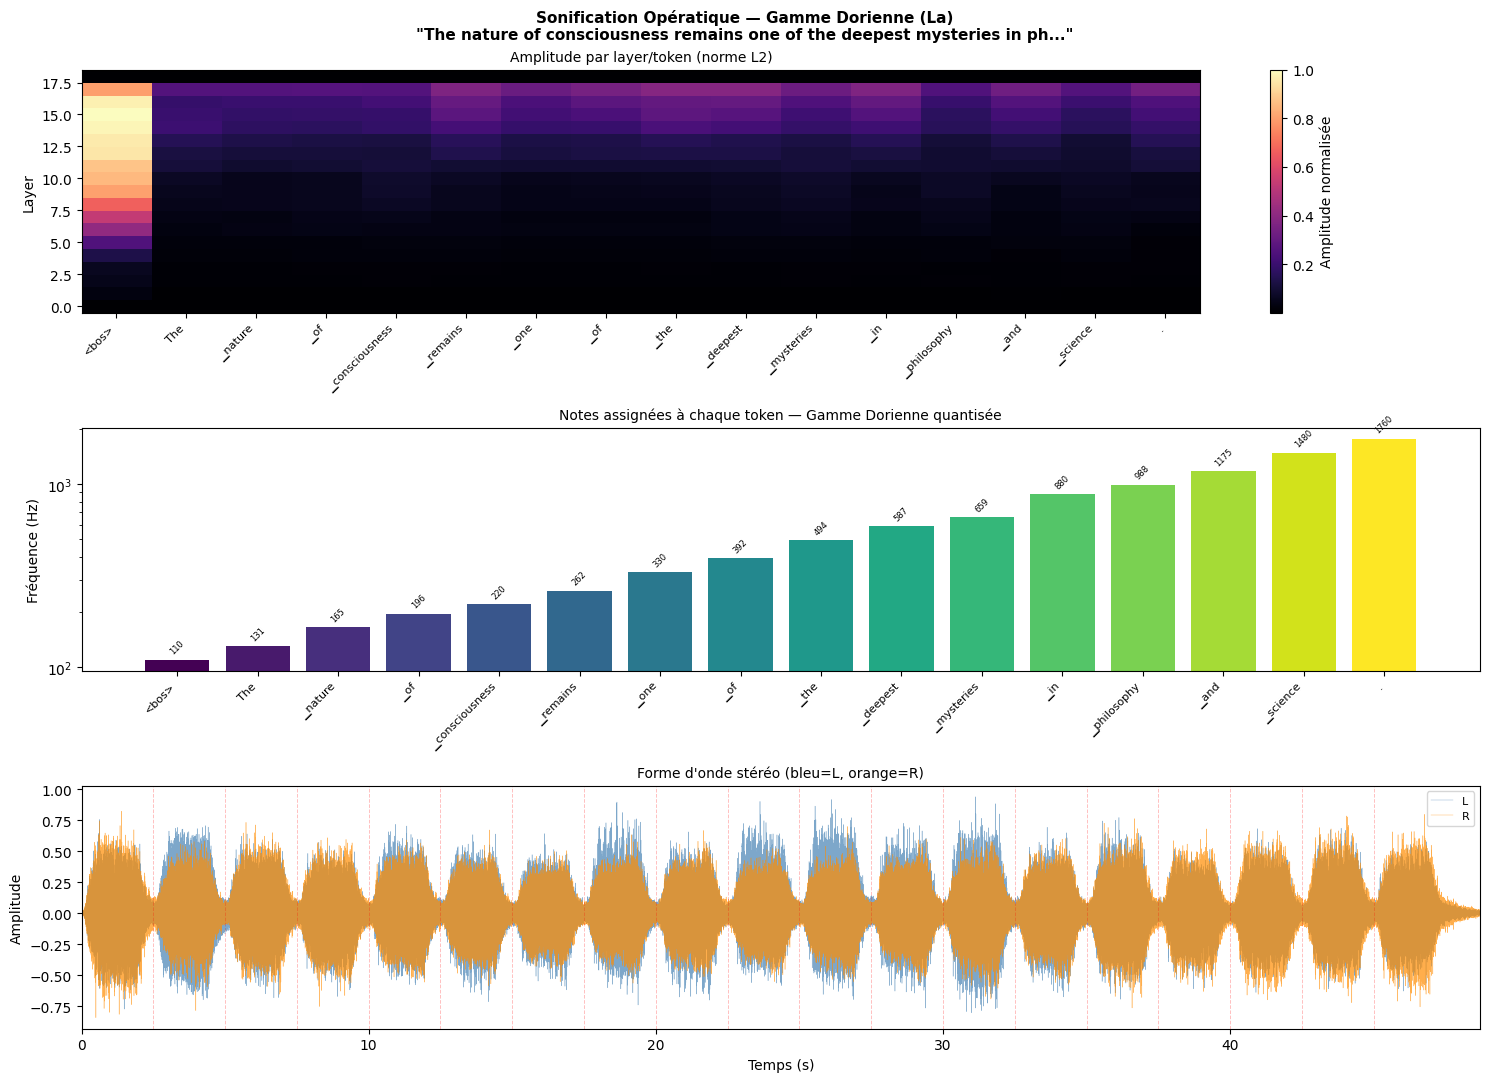

In [ ]:
"""
Sonification Opératique — LLM Thinking Layer by Layer
══════════════════════════════════════════════════════
Version harmonieuse avec :
  • Gamme modale (Dorien) — toutes les fréquences sont des notes réelles
  • Harmoniques riches (synthèse additive, timbre voix/cordes)
  • Enveloppes ADSR par token (attaque douce, decay, sustain, release)
  • Vibrato (légère modulation de fréquence, effet voix humaine)
  • Réverbération convolutive simulée (delay + decay exponentiel)
  • Crossfade long entre layers (transition fluide)
  • Panoramisation stéréo par token (tokens répartis gauche→droite)
"""

import torch
import numpy as np
from scipy.io import wavfile
from scipy.signal import fftconvolve
from sklearn.decomposition import PCA
from transformers import AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt

# ── Config ─────────────────────────────────────────────────────────────────────
MODEL_ID   = "google/gemma-3-270m"
PROMPT     = "The nature of consciousness remains one of the deepest mysteries in philosophy and science."

SR         = 44100
LAYER_DUR  = 2.5        # secondes par layer — plus long = plus opératique
FADE       = 0.6        # crossfade entre layers
OUTPUT_WAV = "llm_operatic.wav"
OUTPUT_PNG = "llm_operatic_viz.png"

# ── Gamme modale Dorienne en La (A Dorian) ────────────────────────────────────
# Intervalles : T, S, T, T, T, S, T  (T=ton, S=demi-ton)
# Sonne mélancolique mais lumineux — parfait pour du chant/opéra
# On génère 4 octaves de notes disponibles
A2 = 110.0  # La2 — note de base (grave)
DORIAN_INTERVALS = [0, 2, 3, 5, 7, 9, 10, 12]  # demi-tons dans l'octave
SCALE_NOTES = []
for octave in range(4):
    for semitones in DORIAN_INTERVALS:
        freq = A2 * (2 ** ((octave * 12 + semitones) / 12))
        SCALE_NOTES.append(freq)
SCALE_NOTES = np.array(sorted(set(SCALE_NOTES)))
print(f"Gamme Dorienne : {len(SCALE_NOTES)} notes de {SCALE_NOTES[0]:.1f}Hz à {SCALE_NOTES[-1]:.1f}Hz")


def snap_to_scale(freq):
    """Quantifie une fréquence vers la note la plus proche dans la gamme."""
    idx = np.argmin(np.abs(SCALE_NOTES - freq))
    return SCALE_NOTES[idx]


# ── Synthèse additive riche (timbre voix/cordes) ─────────────────────────────
def synthesize_voice(freq, duration, amplitude, phase=0.0, vibrato_rate=5.5,
                     vibrato_depth=0.012):
    """
    Génère un son riche avec harmoniques — timbre entre voix et cordes.
    Harmoniques avec amplitudes décroissantes (série de Fourier vocale).
    Vibrato naturel.
    """
    t = np.linspace(0, duration, int(SR * duration), endpoint=False)

    # Vibrato : modulation de fréquence légère (effet voix humaine)
    vibrato = 1.0 + vibrato_depth * np.sin(2 * np.pi * vibrato_rate * t)

    # Phase cumulée avec vibrato
    phase_t = 2 * np.pi * freq * np.cumsum(vibrato) / SR

    # Harmoniques : fondamentale + 6 harmoniques avec pondérations vocales
    # Pondérations inspirées du spectre formantique d'une voix de soprano
    harmonic_weights = np.array([1.0, 0.6, 0.35, 0.2, 0.12, 0.07, 0.04])
    signal = np.zeros(len(t))
    for h, weight in enumerate(harmonic_weights, start=1):
        signal += weight * np.sin(h * phase_t + phase)

    # Normalisation
    signal /= harmonic_weights.sum()
    return signal * amplitude


def adsr_envelope(n_samples, attack=0.15, decay=0.1, sustain=0.75,
                  release=0.25, duration=None):
    """
    Enveloppe ADSR classique.
    attack/decay/release en fraction de la durée totale.
    sustain = niveau (0-1).
    """
    env = np.zeros(n_samples)
    a = int(attack * n_samples)
    d = int(decay * n_samples)
    r = int(release * n_samples)
    s = n_samples - a - d - r

    if a > 0:
        env[:a] = np.linspace(0, 1, a)
    if d > 0:
        env[a:a+d] = np.linspace(1, sustain, d)
    if s > 0:
        env[a+d:a+d+s] = sustain
    if r > 0:
        env[a+d+s:] = np.linspace(sustain, 0, r)
    return env


def reverb(signal, sr, room_size=0.6, damping=0.4, wet=0.35):
    """
    Réverbération simple par convolution avec une IR synthétique.
    room_size : taille de la salle (0-1)
    damping   : absorption haute fréquence
    wet       : mix signal réverbéré (0=sec, 1=tout reverb)
    """
    # Génère une Impulse Response exponentielle décroissante
    ir_duration = room_size * 3.0   # secondes
    ir_samples  = int(sr * ir_duration)
    ir          = np.random.randn(ir_samples)
    decay_curve = np.exp(-damping * np.linspace(0, ir_duration * 6, ir_samples))
    ir          *= decay_curve
    ir          /= np.abs(ir).max() + 1e-9

    # Convolution
    wet_signal = fftconvolve(signal, ir, mode='full')[:len(signal)]
    wet_signal /= np.abs(wet_signal).max() + 1e-9

    return (1 - wet) * signal + wet * wet_signal


# ── 1. Extraction des hidden states ───────────────────────────────────────────
print("\nChargement du modèle...")
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.float32
).to(device)
model.eval()

print(f"Prompt : \"{PROMPT}\"")
inputs  = tokenizer(PROMPT, return_tensors="pt").to(device)
tokens  = tokenizer.convert_ids_to_tokens(inputs.input_ids[0])
N_TOKENS = len(tokens)
print(f"Tokens ({N_TOKENS}) : {tokens}")

with torch.inference_mode():
    outputs = model(**inputs, output_hidden_states=True)

all_hs = np.stack([hs.squeeze(0).cpu().numpy() for hs in outputs.hidden_states])
N_LAYERS, N_TOKENS, HIDDEN = all_hs.shape
print(f"Hidden states : {all_hs.shape}")

# ── 2. Paramètres sonores ─────────────────────────────────────────────────────
# Normes L2 → amplitudes
norms      = np.linalg.norm(all_hs, axis=-1)          # (N_LAYERS, N_TOKENS)
norms_norm = norms / (norms.max() + 1e-9)

# PCA → phases
pca    = PCA(n_components=2)
phases = np.zeros((N_LAYERS, N_TOKENS))
for l in range(N_LAYERS):
    try:
        coords    = pca.fit_transform(all_hs[l])
        phases[l] = np.arctan2(coords[:, 1], coords[:, 0])
    except Exception:
        phases[l] = 0.0

# Fréquences log-spaced → quantifiées sur la gamme Dorienne
freqs_raw = np.exp(np.linspace(np.log(110.0), np.log(1760.0), N_TOKENS))
freqs     = np.array([snap_to_scale(f) for f in freqs_raw])
print(f"\nNotes assignées aux tokens :")
for tok, f in zip(tokens, freqs):
    print(f"  {tok:20s} → {f:.1f} Hz")

# Pan stéréo : tokens répartis de gauche à droite
pan = np.linspace(-1.0, 1.0, N_TOKENS)   # -1=gauche, +1=droite

# ── 3. Génération audio layer par layer ───────────────────────────────────────
samples_per_layer = int(SR * LAYER_DUR)
total_samples     = samples_per_layer * N_LAYERS + int(SR * FADE * 2)
signal_L          = np.zeros(total_samples)
signal_R          = np.zeros(total_samples)

print(f"\nGénération opératique ({N_LAYERS} layers × {LAYER_DUR}s)...")

for l in range(N_LAYERS):
    layer_L = np.zeros(samples_per_layer)
    layer_R = np.zeros(samples_per_layer)

    for tok in range(N_TOKENS):
        amp   = norms_norm[l, tok] ** 0.6   # compression douce (gamma 0.6)
        phase = phases[l, tok]
        freq  = freqs[tok]

        # Vibrato légèrement différent par token (variation naturelle)
        vib_rate  = 4.8 + tok * 0.15
        vib_depth = 0.008 + amp * 0.01

        # Synthèse vocale riche
        voice = synthesize_voice(
            freq, LAYER_DUR, amp,
            phase=phase,
            vibrato_rate=vib_rate,
            vibrato_depth=vib_depth,
        )

        # Enveloppe ADSR (attaque plus longue pour les tokens forts)
        attack_t = 0.1 + amp * 0.1
        env      = adsr_envelope(len(voice), attack=attack_t,
                                 decay=0.08, sustain=0.8, release=0.2)
        voice   *= env

        # Panoramisation stéréo
        gain_L = np.sqrt((1 - pan[tok]) / 2)
        gain_R = np.sqrt((1 + pan[tok]) / 2)
        layer_L += voice * gain_L
        layer_R += voice * gain_R

    # Normalisation du layer
    peak = max(np.abs(layer_L).max(), np.abs(layer_R).max())
    if peak > 1e-9:
        layer_L /= peak
        layer_R /= peak

    # Réverbération par layer (salle plus grande pour layers profonds)
    room = 0.3 + (l / N_LAYERS) * 0.5   # salle qui grandit avec la profondeur
    layer_L = reverb(layer_L, SR, room_size=room, wet=0.3)
    layer_R = reverb(layer_R, SR, room_size=room, wet=0.3)

    # Overlap-add avec fade
    fade_s  = int(SR * FADE)
    env_seg = np.ones(samples_per_layer)
    env_seg[:fade_s]  = np.linspace(0, 1, fade_s)
    env_seg[-fade_s:] = np.linspace(1, 0, fade_s)

    start = l * samples_per_layer
    signal_L[start:start + samples_per_layer] += layer_L * env_seg
    signal_R[start:start + samples_per_layer] += layer_R * env_seg

    layer_name = "Embedding" if l == 0 else f"Layer {l:2d}"
    print(f"  {layer_name} ✓  room={room:.2f}  amp_moy={norms_norm[l].mean():.3f}")

# ── 4. Réverbération globale finale ───────────────────────────────────────────
print("\nRéverbération finale...")
signal_L = reverb(signal_L, SR, room_size=1.2, damping=0.2, wet=0.2)
signal_R = reverb(signal_R, SR, room_size=1.2, damping=0.2, wet=0.2)

# Normalisation globale
peak = max(np.abs(signal_L).max(), np.abs(signal_R).max())
signal_L /= peak + 1e-9
signal_R /= peak + 1e-9

# Stéréo interleaved → int16
stereo = np.stack([signal_L, signal_R], axis=1)
stereo_int16 = (stereo * 30000).astype(np.int16)

wavfile.write(OUTPUT_WAV, SR, stereo_int16)
dur = len(stereo_int16) / SR
print(f"\n✅ Audio stéréo : {OUTPUT_WAV}  ({dur:.1f}s = {dur/60:.1f} min)")

# ── 5. Visualisation ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 11))
fig.suptitle(
    f'Sonification Opératique — Gamme Dorienne (La)\n"{PROMPT[:70]}..."',
    fontsize=11, fontweight='bold'
)

# Heatmap normes
im1 = axes[0].imshow(norms_norm, aspect='auto', cmap='magma', origin='lower')
plt.colorbar(im1, ax=axes[0], label='Amplitude normalisée')
axes[0].set_title("Amplitude par layer/token (norme L2)", fontsize=10)
axes[0].set_xticks(range(N_TOKENS))
axes[0].set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel("Layer")

# Notes assignées
ax2 = axes[1]
bars = ax2.bar(range(N_TOKENS), freqs, color=plt.cm.viridis(np.linspace(0, 1, N_TOKENS)))
ax2.set_xticks(range(N_TOKENS))
ax2.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel("Fréquence (Hz)")
ax2.set_title("Notes assignées à chaque token — Gamme Dorienne quantisée", fontsize=10)
ax2.set_yscale('log')
for i, (tok, f) in enumerate(zip(tokens, freqs)):
    ax2.text(i, f * 1.05, f'{f:.0f}', ha='center', va='bottom', fontsize=6, rotation=45)

# Waveform stéréo
t_audio = np.linspace(0, dur, len(stereo_int16))
axes[2].plot(t_audio, stereo_int16[:, 0].astype(float)/32000,
             linewidth=0.3, color='steelblue', alpha=0.7, label='L')
axes[2].plot(t_audio, stereo_int16[:, 1].astype(float)/32000,
             linewidth=0.3, color='darkorange', alpha=0.7, label='R')
for l in range(1, N_LAYERS):
    axes[2].axvline(x=l * LAYER_DUR, color='red', alpha=0.25,
                    linestyle='--', linewidth=0.7)
axes[2].set_title("Forme d'onde stéréo (bleu=L, orange=R)", fontsize=10)
axes[2].set_xlabel("Temps (s)"); axes[2].set_ylabel("Amplitude")
axes[2].legend(fontsize=8); axes[2].set_xlim(0, dur)

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches='tight')
print(f"✅ Visualisation : {OUTPUT_PNG}")

print(f"""
🎵 Paramètres de la composition :
   Gamme       : La Dorien (mélancolique/lumineux)
   Timbre      : Synthèse additive vocale (7 harmoniques) + vibrato
   Enveloppe   : ADSR (attaque {0.1:.2f}s, release {0.2:.1%})
   Réverb      : Convolutive, salle croissante par layer (0.3→0.8)
   Stéréo      : Panoramisation gauche→droite par position de token
   Durée       : {LAYER_DUR}s/layer × {N_LAYERS} layers = {N_LAYERS*LAYER_DUR:.0f}s
""")

Chargement du modèle (weights only)...


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

Tenseurs chargés : 237
  model.embed_tokens.weight                               (262144, 640)
  model.layers.0.self_attn.q_proj.weight                  (1024, 640)
  model.layers.0.self_attn.k_proj.weight                  (256, 640)
  model.layers.0.self_attn.v_proj.weight                  (256, 640)
  model.layers.0.self_attn.o_proj.weight                  (640, 1024)
  model.layers.0.self_attn.q_norm.weight                  (256,)
  model.layers.0.self_attn.k_norm.weight                  (256,)
  model.layers.0.mlp.gate_proj.weight                     (2048, 640)
  ...

Layers : 18

[I. PROLOGUE — Embeddings]
  Matrice embed : (262144, 640)
  ✓ Prologue — Embeddings (Lydien)  (8.00s)
  ✓ silence  (0.50s)

[II. ANATOMIE — Matrices d'attention]
  ✓ Anatomie — Attention layer 0  (1.50s)
  ✓ Anatomie — Attention layer 1  (1.50s)
  ✓ Anatomie — Attention layer 2  (1.50s)
  ✓ Anatomie — Attention layer 3  (1.50s)
  ✓ Anatomie — Attention layer 4  (1.50s)
  ✓ Anatomie — Attention layer 5  

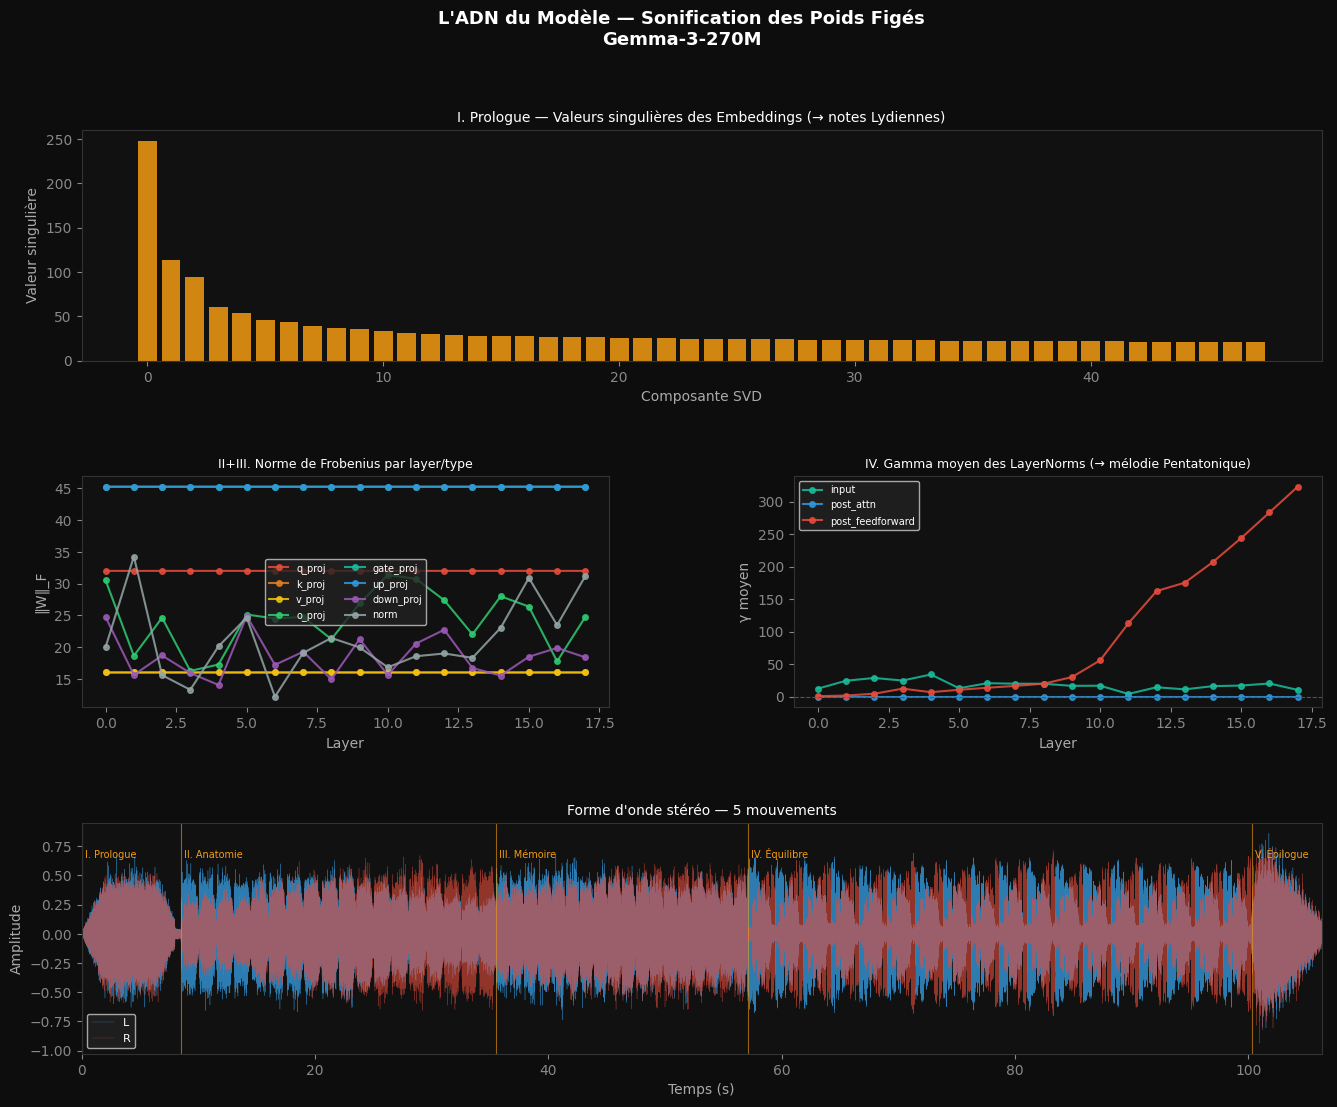

In [ ]:
"""
Sonification des Poids Figés — "L'ADN du Modèle"
══════════════════════════════════════════════════
Transforme les paramètres entraînés (frozen weights) de Gemma-3-270M
en composition musicale. Pas de prompt, pas d'inférence — uniquement
ce que le modèle *est*, pas ce qu'il *fait*.

Structure de la composition (5 mouvements) :
─────────────────────────────────────────────
  I.  PROLOGUE   — Embeddings (vocabulaire intérieur, 256k tokens)
                   → spectre de fréquences des directions sémantiques (SVD)

  II. ANATOMIE   — Valeurs singulières de chaque tenseur d'attention layer/layer
                   → chaque layer = accord, chaque type de matrice = timbre différent

  III. MÉMOIRE   — Poids MLP (gate, up, down) par layer
                   → texture dense, synthèse granulaire simulée

  IV. ÉQUILIBRE  — LayerNorms (gamma) par layer
                   → mélodie pure, une note par layer par norm

  V.  ÉPILOGUE   — Norme de Frobenius de chaque tenseur dans l'ordre
                   → decrescendo progressif vers le silence

Mappings :
  • SVD top-k    → fréquences (valeurs singulières = importance de la direction)
  • Distribution  → timbre (kurtosis → harmoniques, std → amplitude)
  • Profondeur    → réverbération croissante (layer 0 = anechoïque, 17 = cathédrale)
  • Type matrice  → instrument/couleur sonore :
      Q/K = voix hautes   V/O = voix basses
      MLP gate = cordes   MLP up/down = cuivres
      Norm = flûte        Embed = orgue
"""

import torch
import numpy as np
from scipy.io import wavfile
from scipy.signal import fftconvolve
from sklearn.decomposition import TruncatedSVD
from transformers import AutoModelForCausalLM
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time

# ── Config ─────────────────────────────────────────────────────────────────────
MODEL_ID    = "google/gemma-3-270m"
SR          = 44100
OUTPUT_WAV  = "llm_dna_sonification.wav"
OUTPUT_PNG  = "llm_dna_viz.png"

# Durées par mouvement (secondes)
DUR_EMBED   = 8.0   # I.  Prologue — embeddings
DUR_ATT_LAY = 1.5   # II. Anatomie — par layer
DUR_MLP_LAY = 1.2   # III. Mémoire — par layer
DUR_NORM    = 0.4   # IV. Equilibre — par layer
DUR_EPILOG  = 6.0   # V.  Epilogue

SVD_K_EMBED = 48    # top-k valeurs singulières pour embeddings
SVD_K_ATT   = 24    # top-k pour matrices d'attention
SVD_K_MLP   = 16    # top-k pour matrices MLP

FADE        = 0.08  # crossfade général

# ── Gammes modales ─────────────────────────────────────────────────────────────
def build_scale(root_hz, intervals, n_octaves=4):
    notes = []
    for octave in range(n_octaves):
        for st in intervals:
            notes.append(root_hz * 2 ** ((octave * 12 + st) / 12))
    return np.array(sorted(set(notes)))

# I.  Embeddings → Lydien (mystérieux, ouvert)
LYDIAN      = build_scale(65.4,  [0, 2, 4, 6, 7, 9, 11], n_octaves=5)
# II. Attention → Dorien (mélancolique/lumineux)
DORIAN      = build_scale(110.0, [0, 2, 3, 5, 7, 9, 10], n_octaves=4)
# III. MLP     → Phrygien (sombre, tendu)
PHRYGIAN    = build_scale(82.4,  [0, 1, 3, 5, 7, 8, 10], n_octaves=4)
# IV. Norms    → Majeur pentatonique (pur, simple)
PENTATONIC  = build_scale(130.8, [0, 2, 4, 7, 9],        n_octaves=5)
# V.  Epilogue → Mixolydien (résolution ambiguë)
MIXOLYDIAN  = build_scale(55.0,  [0, 2, 4, 5, 7, 9, 10], n_octaves=5)

def snap(freq, scale):
    idx = np.argmin(np.abs(scale - freq))
    return scale[idx]

def freq_from_svd(singular_values, scale, f_min=None, f_max=None):
    """Mappe les valeurs singulières (log-normalisées) vers les notes de la gamme."""
    sv = np.array(singular_values, dtype=float)
    sv = np.log1p(sv)
    sv_min, sv_max = sv.min(), sv.max()
    if sv_max == sv_min:
        sv_norm = np.zeros_like(sv)
    else:
        sv_norm = (sv - sv_min) / (sv_max - sv_min)
    f_min = scale.min() if f_min is None else f_min
    f_max = scale.max() if f_max is None else f_max
    freqs_raw = f_min + sv_norm * (f_max - f_min)
    return np.array([snap(f, scale) for f in freqs_raw])

# ── Synthèse ───────────────────────────────────────────────────────────────────
def synth_voice(freq, dur, amp, harmonics, vibrato_hz=5.2, vibrato_d=0.010, phase=0.0):
    """Synthèse additive avec vibrato. harmonics = [(mult, weight), ...]"""
    t   = np.linspace(0, dur, int(SR * dur), endpoint=False)
    vib = 1.0 + vibrato_d * np.sin(2 * np.pi * vibrato_hz * t)
    phi = 2 * np.pi * freq * np.cumsum(vib) / SR + phase
    sig = sum(w * np.sin(h * phi) for h, w in harmonics)
    sig /= sum(w for _, w in harmonics)
    return sig * amp

# Timbres par type de composant
TIMBER = {
    "embed":  [(1,1.0),(2,0.5),(3,0.3),(4,0.15),(5,0.08),(6,0.04),(7,0.02)],  # orgue
    "q_proj": [(1,1.0),(2,0.4),(3,0.15),(5,0.06)],                            # soprano
    "k_proj": [(1,1.0),(2,0.5),(3,0.25),(4,0.1)],                             # mezzo
    "v_proj": [(1,1.0),(2,0.6),(3,0.3),(4,0.12),(5,0.05)],                    # alto
    "o_proj": [(1,1.0),(2,0.7),(3,0.4),(4,0.2),(5,0.08)],                     # baryton
    "gate":   [(1,1.0),(2,0.8),(3,0.5),(4,0.3),(5,0.15),(6,0.07)],            # cordes
    "up":     [(1,1.0),(2,0.6),(3,0.4),(4,0.2)],                              # cor
    "down":   [(1,1.0),(2,0.5),(3,0.3),(6,0.05)],                             # violoncelle
    "norm":   [(1,1.0),(3,0.1)],                                               # flûte
    "epilog": [(1,1.0),(2,0.3),(4,0.1)],                                       # cloche
}

def adsr(n, a=0.1, d=0.05, s=0.8, r=0.2):
    env = np.ones(n)
    ai  = int(a * n); di = int(d * n); ri = int(r * n); si = n - ai - di - ri
    if ai > 0: env[:ai]           = np.linspace(0, 1, ai)
    if di > 0: env[ai:ai+di]      = np.linspace(1, s, di)
    if si > 0: env[ai+di:ai+di+si]= s
    if ri > 0: env[ai+di+si:]     = np.linspace(s, 0, ri)
    return env

def reverb(sig, room=0.5, wet=0.3, damp=0.4):
    ir_n = int(SR * room * 2.5)
    ir   = np.random.randn(ir_n) * np.exp(-damp * np.linspace(0, room*6, ir_n))
    ir  /= np.abs(ir).max() + 1e-9
    wet_s = fftconvolve(sig, ir, mode='full')[:len(sig)]
    wet_s /= np.abs(wet_s).max() + 1e-9
    return (1 - wet) * sig + wet * wet_s

def build_chord(freqs, amps, dur, timber_key, pan=0.0, room=0.3):
    """Génère un accord stéréo depuis une liste de fréquences."""
    n   = int(SR * dur)
    mix = np.zeros(n)
    env = adsr(n, a=0.12, d=0.06, s=0.82, r=0.18)
    for f, a in zip(freqs, amps):
        if a < 1e-6: continue
        mix += synth_voice(f, dur, float(a), TIMBER[timber_key])
    peak = np.abs(mix).max()
    if peak > 1e-9: mix /= peak
    mix *= env
    mix  = reverb(mix, room=room, wet=min(0.5, room * 0.6))
    # Stéréo
    gl   = np.sqrt((1 - pan) / 2)
    gr   = np.sqrt((1 + pan) / 2)
    return mix * gl, mix * gr

def fade_segment(seg, fade_s=FADE):
    f = int(SR * fade_s)
    seg[:f]  *= np.linspace(0, 1, f)
    seg[-f:] *= np.linspace(1, 0, f)
    return seg

# ── Chargement des poids ───────────────────────────────────────────────────────
print("Chargement du modèle (weights only)...")
device = "cpu"  # poids uniquement, pas d'inférence
model  = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.float32
)
model.eval()
sd     = {k: v.float().numpy() for k, v in model.state_dict().items()}
print(f"Tenseurs chargés : {len(sd)}")
for k, v in list(sd.items())[:8]:
    print(f"  {k:55s} {str(v.shape)}")
print("  ...")

n_layers = model.config.num_hidden_layers
print(f"\nLayers : {n_layers}")

# ── Segments audio ─────────────────────────────────────────────────────────────
segments_L, segments_R = [], []

def add_segment(L, R, label=""):
    segments_L.append(np.array(L, dtype=np.float64))
    segments_R.append(np.array(R, dtype=np.float64))
    print(f"  ✓ {label}  ({len(L)/SR:.2f}s)")

def silence(dur):
    n = int(SR * dur)
    return np.zeros(n), np.zeros(n)

# ══════════════════════════════════════════════════════════════════════════════
# I. PROLOGUE — Embeddings
# ══════════════════════════════════════════════════════════════════════════════
print("\n[I. PROLOGUE — Embeddings]")

embed_key = [k for k in sd if "embed_tokens" in k][0]
E = sd[embed_key]  # (vocab, hidden)
print(f"  Matrice embed : {E.shape}")

svd = TruncatedSVD(n_components=SVD_K_EMBED, random_state=42)
svd.fit(E)
sv   = svd.singular_values_
freqs_embed = freq_from_svd(sv, LYDIAN, LYDIAN.min(), LYDIAN.max() * 0.7)

# Amplitudes ∝ variance expliquée (log pour compression)
amps_embed = np.log1p(sv) / np.log1p(sv.max())

n = int(SR * DUR_EMBED)
L_prolog = np.zeros(n)
R_prolog = np.zeros(n)
env_prolog = adsr(n, a=0.25, d=0.1, s=0.9, r=0.2)

for i, (f, a) in enumerate(zip(freqs_embed, amps_embed)):
    pan   = np.sin(i / SVD_K_EMBED * np.pi * 2) * 0.8  # rotation stéréo
    delay = int(i / SVD_K_EMBED * SR * 1.5)            # entrée progressive
    seg   = synth_voice(f, DUR_EMBED, a * 0.6, TIMBER["embed"],
                        vibrato_hz=4.5 + i*0.04, vibrato_d=0.008)
    sl    = min(n, len(seg))
    gl    = np.sqrt((1 - pan) / 2)
    gr    = np.sqrt((1 + pan) / 2)
    L_prolog[:sl] += seg[:sl] * gl
    R_prolog[:sl] += seg[:sl] * gr

peak = max(np.abs(L_prolog).max(), np.abs(R_prolog).max())
L_prolog = reverb(L_prolog / (peak + 1e-9) * env_prolog, room=0.8, wet=0.35)
R_prolog = reverb(R_prolog / (peak + 1e-9) * env_prolog, room=0.8, wet=0.35)
add_segment(L_prolog, R_prolog, "Prologue — Embeddings (Lydien)")

# Silence de transition
sL, sR = silence(0.5)
add_segment(sL, sR, "silence")

# ══════════════════════════════════════════════════════════════════════════════
# II. ANATOMIE — Attention par layer
# ══════════════════════════════════════════════════════════════════════════════
print("\n[II. ANATOMIE — Matrices d'attention]")

for l in range(n_layers):
    room = 0.2 + (l / n_layers) * 0.7
    pan_base = (l / n_layers) * 2 - 1  # gauche→droite avec la profondeur

    n = int(SR * DUR_ATT_LAY)
    L_layer = np.zeros(n)
    R_layer = np.zeros(n)

    for mat_key, timber, offset_pan in [
        ("q_proj", "q_proj",  0.0),
        ("k_proj", "k_proj",  0.3),
        ("v_proj", "v_proj", -0.3),
        ("o_proj", "o_proj",  0.0),
    ]:
        # Chercher la clé correcte (peut varier selon la version HF)
        candidates = [k for k in sd if f"layers.{l}." in k and mat_key in k]
        if not candidates:
            continue
        W = sd[candidates[0]]
        if W.ndim < 2:
            continue
        k_sv = min(SVD_K_ATT, min(W.shape) - 1)
        if k_sv < 1:
            continue
        svd_w = TruncatedSVD(n_components=k_sv, random_state=42)
        svd_w.fit(W)
        sv_w  = svd_w.singular_values_
        freqs = freq_from_svd(sv_w, DORIAN)
        amps  = np.log1p(sv_w) / np.log1p(sv_w.max() + 1e-9)

        pan = np.clip(pan_base + offset_pan, -1, 1)
        for f, a in zip(freqs, amps * 0.5):
            seg = synth_voice(f, DUR_ATT_LAY, float(a), TIMBER[timber],
                              vibrato_hz=5.0 + l*0.1)
            sl  = min(n, len(seg))
            gl  = np.sqrt((1 - pan) / 2)
            gr  = np.sqrt((1 + pan) / 2)
            L_layer[:sl] += seg[:sl] * gl
            R_layer[:sl] += seg[:sl] * gr

    env  = adsr(n)
    peak = max(np.abs(L_layer).max(), np.abs(R_layer).max()) + 1e-9
    L_layer = reverb(L_layer / peak * env, room=room, wet=0.3)
    R_layer = reverb(R_layer / peak * env, room=room, wet=0.3)
    add_segment(L_layer, R_layer, f"Anatomie — Attention layer {l}")

# ══════════════════════════════════════════════════════════════════════════════
# III. MÉMOIRE — MLP par layer
# ══════════════════════════════════════════════════════════════════════════════
print("\n[III. MÉMOIRE — MLP par layer]")

for l in range(n_layers):
    room = 0.3 + (l / n_layers) * 0.6
    n    = int(SR * DUR_MLP_LAY)
    L_mlp = np.zeros(n)
    R_mlp = np.zeros(n)

    for mat_key, timber, pan_offset in [
        ("gate_proj", "gate",  0.5),
        ("up_proj",   "up",   -0.5),
        ("down_proj", "down",  0.0),
    ]:
        candidates = [k for k in sd if f"layers.{l}." in k and mat_key in k]
        if not candidates:
            continue
        W = sd[candidates[0]]
        if W.ndim < 2:
            continue
        k_sv = min(SVD_K_MLP, min(W.shape) - 1)
        if k_sv < 1:
            continue
        svd_w = TruncatedSVD(n_components=k_sv, random_state=42)
        svd_w.fit(W)
        sv_w  = svd_w.singular_values_
        freqs = freq_from_svd(sv_w, PHRYGIAN)
        amps  = np.log1p(sv_w) / np.log1p(sv_w.max() + 1e-9) * 0.6

        pan = np.clip(-0.6 + l/n_layers * 1.2 + pan_offset*0.3, -1, 1)
        for f, a in zip(freqs, amps):
            seg = synth_voice(f, DUR_MLP_LAY, float(a), TIMBER[timber],
                              vibrato_hz=4.0 + l*0.08, vibrato_d=0.012)
            sl  = min(n, len(seg))
            gl  = np.sqrt((1 - pan) / 2)
            gr  = np.sqrt((1 + pan) / 2)
            L_mlp[:sl] += seg[:sl] * gl
            R_mlp[:sl] += seg[:sl] * gr

    env  = adsr(n, a=0.08, r=0.25)
    peak = max(np.abs(L_mlp).max(), np.abs(R_mlp).max()) + 1e-9
    L_mlp = reverb(L_mlp / peak * env, room=room, wet=0.35)
    R_mlp = reverb(R_mlp / peak * env, room=room, wet=0.35)
    add_segment(L_mlp, R_mlp, f"Mémoire — MLP layer {l}")

# ══════════════════════════════════════════════════════════════════════════════
# IV. ÉQUILIBRE — LayerNorms
# ══════════════════════════════════════════════════════════════════════════════
print("\n[IV. ÉQUILIBRE — LayerNorms]")

norm_keys_all = [k for k in sd if "norm" in k.lower()]
n_seg = int(SR * DUR_NORM)

L_norm_full = []
R_norm_full = []

for l in range(n_layers):
    norm_keys = [k for k in norm_keys_all if f"layers.{l}." in k]
    for i, nk in enumerate(sorted(norm_keys)):
        w     = sd[nk]  # (hidden_size,) vecteur gamma
        mean  = float(w.mean())
        std   = float(w.std())
        # La moyenne du gamma → fréquence de base
        f_raw = 200 + mean * 500 + l * 30
        f     = snap(abs(f_raw), PENTATONIC)
        amp   = np.clip(std * 8, 0.1, 1.0)
        pan   = (i / max(1, len(norm_keys)-1)) * 2 - 1

        seg = synth_voice(f, DUR_NORM, amp * 0.7, TIMBER["norm"],
                          vibrato_hz=6.0, vibrato_d=0.005)
        seg *= adsr(n_seg, a=0.05, r=0.4)
        seg  = reverb(seg, room=0.2 + l/n_layers*0.4, wet=0.2)
        gl   = np.sqrt((1 - pan) / 2)
        gr   = np.sqrt((1 + pan) / 2)
        L_norm_full.append(seg * gl)
        R_norm_full.append(seg * gr)

add_segment(np.concatenate(L_norm_full),
            np.concatenate(R_norm_full),
            "Équilibre — LayerNorms (Pentatonique)")

# ══════════════════════════════════════════════════════════════════════════════
# V. ÉPILOGUE — Normes de Frobenius
# ══════════════════════════════════════════════════════════════════════════════
print("\n[V. ÉPILOGUE — Normes de Frobenius]")

all_keys   = [k for k in sd if "embed" not in k or "output" in k]
frob_norms = [(k, float(np.linalg.norm(sd[k]))) for k in all_keys]
frob_norms.sort(key=lambda x: x[1], reverse=True)

n_epilog  = int(SR * DUR_EPILOG)
L_epilog  = np.zeros(n_epilog)
R_epilog  = np.zeros(n_epilog)
max_frob  = max(fn for _, fn in frob_norms) + 1e-9

for i, (name, fn) in enumerate(frob_norms):
    t_start = i / len(frob_norms) * DUR_EPILOG
    amp     = (fn / max_frob) ** 0.4
    # Decrescendo : les tenseurs les plus importants sonnent d'abord
    f_raw   = 110 * (fn / max_frob) * 8
    f       = snap(max(30, f_raw), MIXOLYDIAN)
    dur_note= max(0.05, DUR_EPILOG - t_start)
    note_n  = min(int(SR * dur_note), n_epilog - int(SR * t_start))
    if note_n < 100:
        continue
    seg  = synth_voice(f, dur_note, amp * 0.3, TIMBER["epilog"],
                       vibrato_hz=3.5, vibrato_d=0.006)
    seg  = seg[:note_n] * np.linspace(1, 0, note_n)  # decrescendo naturel
    pan  = np.sin(i * 0.4) * 0.9
    gl   = np.sqrt((1 - pan) / 2)
    gr   = np.sqrt((1 + pan) / 2)
    start_idx = int(SR * t_start)
    L_epilog[start_idx:start_idx + note_n] += seg * gl
    R_epilog[start_idx:start_idx + note_n] += seg * gr

peak = max(np.abs(L_epilog).max(), np.abs(R_epilog).max()) + 1e-9
L_epilog = reverb(L_epilog / peak, room=1.5, wet=0.45, damp=0.2)
R_epilog = reverb(R_epilog / peak, room=1.5, wet=0.45, damp=0.2)
add_segment(L_epilog, R_epilog, "Épilogue — Normes de Frobenius (Mixolydien)")

# ══════════════════════════════════════════════════════════════════════════════
# Assemblage final
# ══════════════════════════════════════════════════════════════════════════════
print("\nAssemblage...")
L_full = np.concatenate(segments_L)
R_full = np.concatenate(segments_R)

# Réverbération globale finale très douce
L_full = reverb(L_full, room=2.0, wet=0.12, damp=0.15)
R_full = reverb(R_full, room=2.0, wet=0.12, damp=0.15)

# Normalisation
peak   = max(np.abs(L_full).max(), np.abs(R_full).max()) + 1e-9
L_full /= peak
R_full /= peak

stereo = np.stack([L_full, R_full], axis=1)
stereo_int16 = (stereo * 30000).astype(np.int16)
wavfile.write(OUTPUT_WAV, SR, stereo_int16)

dur_total = len(stereo_int16) / SR
print(f"\n✅ {OUTPUT_WAV}  ({dur_total:.1f}s = {dur_total/60:.1f} min)")

# ══════════════════════════════════════════════════════════════════════════════
# Visualisation
# ══════════════════════════════════════════════════════════════════════════════
print("Visualisation...")

# Normes de Frobenius par type de tenseur
types  = ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj","norm"]
colors = ["#e74c3c","#e67e22","#f1c40f","#2ecc71","#1abc9c","#3498db","#9b59b6","#95a5a6"]

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#0d0d0d')
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)
fig.suptitle("L'ADN du Modèle — Sonification des Poids Figés\nGemma-3-270M",
             fontsize=13, fontweight='bold', color='white')

# Panel 1 : SVD embeddings
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('#111111')
sv_embed = svd.singular_values_
ax1.bar(range(len(sv_embed)), sv_embed, color='#f39c12', alpha=0.85)
ax1.set_title("I. Prologue — Valeurs singulières des Embeddings (→ notes Lydiennes)", color='white', fontsize=10)
ax1.set_xlabel("Composante SVD", color='#aaa'); ax1.set_ylabel("Valeur singulière", color='#aaa')
ax1.tick_params(colors='#888'); [s.set_color('#333') for s in ax1.spines.values()]

# Panel 2 : Normes de Frobenius par layer par type
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('#111111')
for t, col in zip(types, colors):
    norms_by_layer = []
    for l in range(n_layers):
        keys = [k for k in sd if f"layers.{l}." in k and t in k]
        if keys:
            norms_by_layer.append(np.linalg.norm(sd[keys[0]]))
        else:
            norms_by_layer.append(0)
    if any(n > 0 for n in norms_by_layer):
        ax2.plot(range(n_layers), norms_by_layer, 'o-', color=col,
                 linewidth=1.5, markersize=4, label=t, alpha=0.85)
ax2.set_title("II+III. Norme de Frobenius par layer/type", color='white', fontsize=9)
ax2.set_xlabel("Layer", color='#aaa'); ax2.set_ylabel("‖W‖_F", color='#aaa')
ax2.legend(fontsize=7, facecolor='#222', labelcolor='white', ncol=2)
ax2.tick_params(colors='#888'); [s.set_color('#333') for s in ax2.spines.values()]

# Panel 3 : LayerNorm gamma moyens
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('#111111')
norm_types = ["input_layernorm","post_attn_layernorm","post_feedforward_layernorm"]
norm_colors = ["#1abc9c","#3498db","#e74c3c"]
for nt, nc in zip(norm_types, norm_colors):
    means = []
    for l in range(n_layers):
        keys = [k for k in sd if f"layers.{l}." in k and nt in k]
        if keys:
            means.append(float(sd[keys[0]].mean()))
        else:
            means.append(0)
    ax3.plot(range(n_layers), means, 'o-', color=nc, lw=1.5, ms=4,
             label=nt.replace("_layernorm",""), alpha=0.85)
ax3.axhline(0, color='#555', linestyle='--', lw=0.8)
ax3.set_title("IV. Gamma moyen des LayerNorms (→ mélodie Pentatonique)", color='white', fontsize=9)
ax3.set_xlabel("Layer", color='#aaa'); ax3.set_ylabel("γ moyen", color='#aaa')
ax3.legend(fontsize=7, facecolor='#222', labelcolor='white')
ax3.tick_params(colors='#888'); [s.set_color('#333') for s in ax3.spines.values()]

# Panel 4 : Waveform finale
ax4 = fig.add_subplot(gs[2, :])
ax4.set_facecolor('#111111')
t_audio = np.linspace(0, dur_total, len(stereo_int16))
ax4.plot(t_audio, stereo_int16[:, 0].astype(float)/32000,
         lw=0.25, color='#3498db', alpha=0.8, label='L')
ax4.plot(t_audio, stereo_int16[:, 1].astype(float)/32000,
         lw=0.25, color='#e74c3c', alpha=0.6, label='R')

# Marqueurs des 5 mouvements
mvt_dur = DUR_EMBED + 0.5
mvt_starts = {
    "I. Prologue": 0,
    "II. Anatomie": mvt_dur,
    "III. Mémoire": mvt_dur + n_layers * DUR_ATT_LAY,
    "IV. Équilibre": mvt_dur + n_layers * (DUR_ATT_LAY + DUR_MLP_LAY),
    "V. Épilogue": dur_total - DUR_EPILOG,
}
for label, t_start in mvt_starts.items():
    ax4.axvline(x=t_start, color='#f39c12', alpha=0.6, lw=0.8)
    ax4.text(t_start + 0.3, 0.65, label, color='#f39c12', fontsize=7, rotation=0)

ax4.set_title("Forme d'onde stéréo — 5 mouvements", color='white', fontsize=10)
ax4.set_xlabel("Temps (s)", color='#aaa'); ax4.set_ylabel("Amplitude", color='#aaa')
ax4.set_xlim(0, dur_total); ax4.legend(fontsize=8, facecolor='#222', labelcolor='white')
ax4.tick_params(colors='#888'); [s.set_color('#333') for s in ax4.spines.values()]

plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
print(f"✅ {OUTPUT_PNG}")

print(f"""
🎼 COMPOSITION : "L'ADN du Modèle"
   I.  Prologue   {DUR_EMBED:.0f}s  — Embeddings   → Gamme Lydienne   (orgue)
   II. Anatomie   {n_layers*DUR_ATT_LAY:.0f}s  — Attention    → Gamme Dorienne  (voix SATB)
   III.Mémoire    {n_layers*DUR_MLP_LAY:.0f}s  — MLP          → Gamme Phrygienne(cordes/cuivres)
   IV. Équilibre  {n_layers*len(norm_types)*DUR_NORM:.0f}s  — LayerNorms   → Pentatonique    (flûte)
   V.  Épilogue   {DUR_EPILOG:.0f}s  — Frobenius    → Mixolydien     (cloches)
   ────────────────────────────────────────────────
   Total : {dur_total:.1f}s = {dur_total/60:.1f} min
   Source: {len(sd)} tenseurs, ~270M paramètres
   Chaque note = une propriété spectrale réelle du modèle
""")

In [ ]:
import argparse
import sys
import numpy as np
from scipy.io import wavfile
from scipy.signal import butter, sosfilt
from scipy.stats import kurtosis as scipy_kurtosis
from sklearn.decomposition import TruncatedSVD

# ── Parsing arguments ──────────────────────────────────────────────────────────
parser = argparse.ArgumentParser(description="LLM House — weights → music")
parser.add_argument("--model",  default="google/gemma-3-270m", help="HuggingFace model ID")
parser.add_argument("--bpm",    type=int,   default=128,  help="BPM (120=deep, 128=house, 140=techno)")
parser.add_argument("--bars",   type=int,   default=32,   help="Nombre de bars (32=1min, 64=2min)")
parser.add_argument("--output", default="llm_house_weights.wav", help="Fichier de sortie")
parser.add_argument("--seed",   type=int,   default=42,   help="Graine aléatoire")

# Fix for Colab: parse only known arguments
args = parser.parse_args([])

np.random.seed(args.seed)

MODEL_ID   = args.model
BPM        = args.bpm
BARS       = args.bars
OUTPUT_WAV = args.output
SR         = 44100
BEAT       = 60.0 / BPM
BAR        = BEAT * 4
TOTAL_S    = BAR * BARS
N_TOTAL    = int(SR * TOTAL_S)

print(f"""
╔══════════════════════════════════════════════════════╗
║  LLM HOUSE — Poids Réels                            ║
╠══════════════════════════════════════════════════════╣
║  Modèle  : {MODEL_ID:<41}║
║  BPM     : {BPM:<41}║
║  Bars    : {BARS:<41}║
║  Durée   : {TOTAL_S:.0f}s = {TOTAL_S/60:.1f} min{'':<30}║
║  Output  : {OUTPUT_WAV:<41}║
╚══════════════════════════════════════════════════════╝
""")

# ── Gammes modales (en Hz, pas de noms de notes) ───────────────────────────────
def build_scale_hz(root, semitones, octaves=4):
    notes = []
    for o in range(octaves):
        for st in semitones:
            notes.append(root * 2 ** ((o * 12 + st) / 12))
    return np.array(sorted(set(notes)))

# Gamme de base : La (A = 55 Hz, octave 1)
ROOT = 55.0

LYDIAN    = build_scale_hz(ROOT, [0,2,4,6,7,9,11], octaves=5)   # intro
DORIAN    = build_scale_hz(ROOT, [0,2,3,5,7,9,10], octaves=5)   # buildup
PHRYGIAN  = build_scale_hz(ROOT, [0,1,3,5,7,8,10], octaves=5)   # drop
AEOLIAN   = build_scale_hz(ROOT, [0,2,3,5,7,8,10], octaves=5)   # outro (mineur nat.)

# Accords par section (indices dans la gamme correspondante)
# Format : liste de fréquences Hz directement
def chord_from_scale(scale, degrees, octave_shift=0):
    """Sélectionne des degrés (0-indexés) dans une gamme."""
    idxs = [min(d + octave_shift * 7, len(scale)-1) for d in degrees]
    return [float(scale[i]) for i in idxs]

# Am i-VI-III-VII dans chaque mode, changement toutes les 2 bars
CHORDS_BY_SECTION = {
    "intro":   [chord_from_scale(LYDIAN,   [0,2,4,7],  octave_shift=2),   # I
                chord_from_scale(LYDIAN,   [3,5,7,10], octave_shift=2),   # IV
                chord_from_scale(LYDIAN,   [4,7,9,11], octave_shift=2),   # V
                chord_from_scale(LYDIAN,   [2,4,7,9],  octave_shift=2)],  # III
    "buildup": [chord_from_scale(DORIAN,   [0,2,4,7],  octave_shift=2),
                chord_from_scale(DORIAN,   [5,7,9,12], octave_shift=2),
                chord_from_scale(DORIAN,   [3,5,7,10], octave_shift=2),
                chord_from_scale(DORIAN,   [4,7,9,11], octave_shift=2)],
    "drop":    [chord_from_scale(PHRYGIAN, [0,2,4,7],  octave_shift=2),
                chord_from_scale(PHRYGIAN, [5,7,9,12], octave_shift=2),
                chord_from_scale(PHRYGIAN, [3,5,7,10], octave_shift=2),
                chord_from_scale(PHRYGIAN, [6,8,10,13],octave_shift=2)],
    "outro":   [chord_from_scale(AEOLIAN,  [0,2,4,7],  octave_shift=2),
                chord_from_scale(AEOLIAN,  [5,7,9,12], octave_shift=2),
                chord_from_scale(AEOLIAN,  [3,5,7,10], octave_shift=2),
                chord_from_scale(AEOLIAN,  [0,2,4,7],  octave_shift=2)],
}

def snap(freq, scale):
    return float(scale[np.argmin(np.abs(scale - np.clip(freq, scale.min(), scale.max())))])

# ── Utilitaires signal ─────────────────────────────────────────────────────────
def lpf(sig, fc, order=2):
    fc = float(np.clip(fc, 20, SR * 0.49))
    return sosfilt(butter(order, fc, fs=SR, output='sos'), sig)

def hpf(sig, fc, order=2):
    fc = float(np.clip(fc, 20, SR * 0.49))
    return sosfilt(butter(order, fc, btype='high', fs=SR, output='sos'), sig)

def bpf(sig, lo, hi, order=3):
    lo = float(np.clip(lo, 20, SR * 0.45))
    hi = float(np.clip(hi, lo + 10, SR * 0.49))
    return sosfilt(butter(order, [lo, hi], btype='band', fs=SR, output='sos'), sig)

def adsr_env(n, attack=0.1, decay=0.05, sustain=0.85, release=0.2):
    env = np.ones(n)
    ai  = max(1, int(attack * n))
    di  = max(1, int(decay * n))
    ri  = max(1, int(release * n))
    si  = max(0, n - ai - di - ri)
    env[:ai]           = np.linspace(0, 1, ai)
    env[ai:ai+di]      = np.linspace(1, sustain, di)
    env[ai+di:ai+di+si]= sustain
    env[ai+di+si:]     = np.linspace(sustain, 0, ri)
    return env

def reverb(sig, wet=0.25, delays_ms=None):
    if delays_ms is None:
        delays_ms = [31, 47, 63, 89, 107]
    gains = [0.45, 0.38, 0.30, 0.23, 0.18]
    out   = sig.copy()
    for ms, g in zip(delays_ms, gains):
        d = int(SR * ms / 1000)
        if d < len(sig):
            tmp      = np.zeros_like(sig)
            tmp[d:]  = sig[:-d] * g
            out     += tmp
    peak = np.abs(out).max()
    if peak > 1e-9:
        out /= peak
    return (1 - wet) * sig + wet * out

def norm01(x):
    mn, mx = x.min(), x.max()
    return (x - mn) / (mx - mn + 1e-9)

# ── Synthèse drums ─────────────────────────────────────────────────────────────
def make_kick(punch=150, tail=42, dur=0.55):
    t    = np.linspace(0, dur, int(SR * dur), endpoint=False)
    freq = punch * np.exp(-22 * t) + tail
    phi  = 2 * np.pi * np.cumsum(freq) / SR
    body = np.sin(phi)
    click= np.exp(-160 * t) * np.random.randn(len(t)) * 0.18
    env  = np.exp(-6 * t)
    sat  = np.tanh((body + click) * env * 2.5) / np.tanh(2.5)
    return np.clip(sat * 0.95, -1, 1)

def make_clap(dur=0.20):
    t    = np.linspace(0, dur, int(SR * dur), endpoint=False)
    n    = bpf(np.random.randn(len(t)), 900, 5500)
    tone = np.sin(2 * np.pi * 210 * t) * np.exp(-35 * t) * 0.3
    env  = np.exp(-22 * t) * (1 + 0.35 * np.sin(2 * np.pi * 45 * t))
    return np.clip((n + tone) * env * 0.78, -1, 1)

def make_hihat(open_=False, vel=0.6, brightness=1.0):
    dur  = 0.30 if open_ else 0.055
    t    = np.linspace(0, dur, int(SR * dur), endpoint=False)
    n    = bpf(np.random.randn(len(t)), 6000 * brightness, 18000)
    env  = np.exp((-9 if open_ else -55) * t)
    return n * env * vel * 0.42

def make_rim(dur=0.08):
    t   = np.linspace(0, dur, int(SR * dur), endpoint=False)
    n   = bpf(np.random.randn(len(t)), 1500, 4000)
    tone= np.sin(2 * np.pi * 1200 * t) * np.exp(-80 * t)
    env = np.exp(-50 * t)
    return (n * 0.6 + tone * 0.4) * env * 0.55

# ── Synthèse mélodique ─────────────────────────────────────────────────────────
def make_bass(freq, dur, cutoff=600, resonance=1.0):
    """Bassline acid — saw filtrée, saturation tanh, résonance variable."""
    t   = np.linspace(0, dur, int(SR * dur), endpoint=False)
    # Saw riche (8 harmoniques)
    saw = sum((1 / k) * np.sin(2 * np.pi * k * freq * t) for k in range(1, 9)) * 0.42
    # Filtre avec résonance simulée (pré-emphasis + lpf)
    pre = saw + np.gradient(saw) * resonance * 0.08
    sig = lpf(pre, cutoff, order=3)
    # Saturation douce
    sat = np.tanh(sig * 2.8) / np.tanh(2.8)
    # Enveloppe AD (pas de sustain long pour le punch acid)
    n   = len(t)
    env = np.ones(n)
    ai  = int(SR * 0.005)   # attack 5ms
    ri  = int(SR * 0.03)    # release 30ms en fin de note
    env[:ai]  = np.linspace(0, 1, ai)
    env[-ri:] = np.linspace(1, 0, ri)
    decay = np.exp(-1.8 * t) * 0.65 + 0.35
    return sat * env * decay * 0.88

def make_pad(freqs, dur, amp=0.38, detune=0.0035):
    """Supersaw pad — 3 voix détuned par note, filtre doux."""
    n   = int(SR * dur)
    t   = np.linspace(0, dur, n, endpoint=False)
    mix = np.zeros(n)
    for freq in freqs:
        for det in [-detune, 0.0, detune]:
            f   = freq * (1 + det)
            # Supersaw = somme de saws légèrement déphasées
            saw = sum((1/k) * np.sin(2*np.pi*k*f*t + np.random.uniform(0, 6.283))
                      for k in range(1, 7)) * 0.28
            mix += saw
    sig = lpf(mix, 3800, order=2)
    env = adsr_env(n, attack=0.15, decay=0.08, sustain=0.88, release=0.35)
    peak = np.abs(sig).max()
    return sig / (peak + 1e-9) * env * amp

def make_lead(freq, dur, amp=0.45, wave="square"):
    """Lead synth — onde carrée ou dent de scie filtrée."""
    t   = np.linspace(0, dur, int(SR * dur), endpoint=False)
    if wave == "square":
        sig = np.tanh(3.5 * np.sign(np.sin(2 * np.pi * freq * t)))
    else:
        sig = sum((1/k) * np.sin(2*np.pi*k*freq*t) for k in range(1, 7)) * 0.45
    sig = lpf(sig, 4000, order=2)
    n   = len(t)
    env = np.ones(n)
    ai  = max(1, int(SR * 0.008))
    ri  = max(1, int(SR * 0.012))
    env[:ai]  = np.linspace(0, 1, ai)
    env[-ri:] = np.linspace(1, 0, ri)
    decay = np.exp(-4 * t) * 0.55 + 0.45
    return sig * env * decay * amp * 0.38

# ── Track stéréo + helpers ─────────────────────────────────────────────────────
track = np.zeros((N_TOTAL, 2), dtype=np.float64)

def bs(bar):  return int(bar * BAR * SR)
def bts(beat): return int(beat * BEAT * SR)

def add(sample, start, pan=0.0, amp=1.0):
    if start >= N_TOTAL or len(sample) == 0:
        return
    n  = min(len(sample), N_TOTAL - start)
    gl = float(np.sqrt(np.clip((1 - pan) / 2, 0, 1))) * amp
    gr = float(np.sqrt(np.clip((1 + pan) / 2, 0, 1))) * amp
    track[start:start + n, 0] += sample[:n] * gl
    track[start:start + n, 1] += sample[:n] * gr

def section_of(bar):
    q = BARS // 4
    if bar < q:         return "intro"
    elif bar < 2 * q:   return "buildup"
    elif bar < 3 * q:   return "drop"
    else:               return "outro"

def fade_amp(bar):
    """Fade out sur les 4 derniers bars."""
    fade_start = BARS - 4
    if bar < fade_start:
        return 1.0
    return float(max(0.0, 1.0 - (bar - fade_start) / 4.0))

# ══════════════════════════════════════════════════════════════════════════════
# Chargement du modèle
# ══════════════════════════════════════════════════════════════════════════════
print("Chargement du modèle (poids uniquement, pas d'inférence)...")
try:
    import torch
    from transformers import AutoModelForCausalLM
except ImportError:
    print("ERREUR : torch et/ou transformers non installés.")
    print("  pip install torch transformers")
    sys.exit(1)

model    = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32)
model.eval()
sd       = {k: v.detach().float().numpy() for k, v in model.state_dict().items()}
n_layers = model.config.num_hidden_layers
print(f"  {n_layers} layers  |  {len(sd)} tenseurs  |  "
      f"~{sum(v.size for v in sd.values())/1e6:.0f}M paramètres")
del model   # libérer la RAM dès que possible

# ══════════════════════════════════════════════════════════════════════════════
# Extraction des paramètres musicaux depuis les poids réels
# ══════════════════════════════════════════════════════════════════════════════
print("Extraction des données musicales depuis les poids...")

def get_layer_tensor(layer, name):
    """Renvoie le numpy array du tenseur 'name' au layer donné, ou None."""
    keys = [k for k in sd if f"layers.{layer}." in k and name in k]
    return sd[keys[0]] if keys else None

# ── 1. SVD des matrices Q par groupe de layers → fréquences des pads ──────────
# On calcule les SVD sur les vraies matrices de poids Q_proj
# Les valeurs singulières représentent les "directions principales" apprises
print("  [1/5] SVD matrices Q par section...")
sections = ["intro", "buildup", "drop", "outro"]
svd_freqs_by_section = {}   # section → liste de fréquences pour le pad

for sec_idx, sec in enumerate(sections):
    layer_lo = sec_idx * (n_layers // 4)
    layer_hi = layer_lo + (n_layers // 4)
    all_sv   = []
    scale_for_sec = [LYDIAN, DORIAN, PHRYGIAN, AEOLIAN][sec_idx]

    for l in range(layer_lo, layer_hi):
        W = get_layer_tensor(l, "q_proj")
        if W is None or W.ndim < 2:
            continue
        k   = min(16, min(W.shape) - 1)
        svd = TruncatedSVD(n_components=k, random_state=42)
        svd.fit(W)
        all_sv.extend(svd.singular_values_.tolist())

    if not all_sv:
        svd_freqs_by_section[sec] = CHORDS_BY_SECTION[sec]
        continue

    sv    = np.array(all_sv)
    sv_n  = norm01(np.log1p(sv))
    f_lo  = scale_for_sec[len(scale_for_sec) // 3]    # médium
    f_hi  = scale_for_sec[len(scale_for_sec) * 2 // 3]
    # 4 accords par section = 4 groupes de SV
    chord_svs = np.array_split(sv_n, 4)
    chords    = []
    for g in chord_svs:
        if len(g) == 0:
            chords.append(CHORDS_BY_SECTION[sec][0])
            continue
        # Sélectionner 4 fréquences dans les quartiles du groupe
        quartiles = np.percentile(g, [10, 35, 65, 90])
        freqs     = [snap(f_lo + q * (f_hi - f_lo), scale_for_sec) for q in quartiles]
        # S'assurer qu'on a au moins 2 octaves de séparation min-max
        freqs     = sorted(set(freqs))
        chords.append(freqs)
    svd_freqs_by_section[sec] = chords

# ── 2. Norme de Frobenius down_proj par layer → séquence bassline ─────────────
print("  [2/5] Normes Frobenius down_proj → bassline...")
frob_down = []
for l in range(n_layers):
    W = get_layer_tensor(l, "down_proj")
    frob_down.append(float(np.linalg.norm(W)) if W is not None else 0.0)

frob_arr  = norm01(np.array(frob_down))
# Bassline sur gamme Am pentatonique grave
BASS_PENTA = build_scale_hz(ROOT / 2, [0, 3, 5, 7, 10], octaves=3)
bass_notes = [snap(BASS_PENTA.min() + v * (BASS_PENTA.max() - BASS_PENTA.min()), BASS_PENTA)
              for v in frob_arr]
# Répéter pour couvrir tous les bars
bass_notes = bass_notes * ((BARS * 8 // len(bass_notes)) + 2)

# ── 3. Écart-type gate_proj par layer → cutoff filtre acid ────────────────────
print("  [3/5] Std gate_proj → cutoff acid...")
gate_stds = []
for l in range(n_layers):
    W = get_layer_tensor(l, "gate_proj")
    gate_stds.append(float(W.std()) if W is not None else 0.0)

gate_stds_arr = norm01(np.array(gate_stds))
cutoff_notes  = 300 + gate_stds_arr * 1100  # 300→1400 Hz
cutoff_notes  = list(cutoff_notes) * ((BARS // len(cutoff_notes)) + 2)

# ── 4. Kurtosis v_proj par layer → résonance acid ────────────────────────────
print("  [4/5] Kurtosis v_proj → résonance...")
v_kurtosis = []
for l in range(n_layers):
    W = get_layer_tensor(l, "v_proj")
    if W is not None:
        v_kurtosis.append(float(scipy_kurtosis(W.ravel())))
    else:
        v_kurtosis.append(0.0)

kurt_arr   = norm01(np.array(v_kurtosis))
resonance  = 0.4 + kurt_arr * 2.6   # 0.4→3.0
resonance  = list(resonance) * ((BARS // len(resonance)) + 2)

# ── 5. Gamma layernorm par layer → vélocité hats + pan arpège ────────────────
print("  [5/5] LayerNorm gamma → vélocité hats + pan arpège...")
gamma_means = []
gamma_stds  = []
for l in range(n_layers):
    W = get_layer_tensor(l, "input_layernorm")
    if W is not None:
        gamma_means.append(float(W.mean()))
        gamma_stds.append(float(W.std()))
    else:
        gamma_means.append(0.0)
        gamma_stds.append(0.0)

hat_vels = list(0.3 + norm01(np.array(np.abs(gamma_means))) * 0.7)
hat_vels *= ((BARS // len(hat_vels)) + 2)

# Pan arpège : angle PCA de la layernorm (direction principale dans l'espace gamma)
arp_pans = []
for l in range(n_layers):
    W = get_layer_tensor(l, "input_layernorm")
    if W is not None and len(W) >= 2:
        # La norme de la 1ère moitié vs 2ème → asymétrie → pan
        half = len(W) // 2
        diff = float(np.linalg.norm(W[:half]) - np.linalg.norm(W[half:]))
        arp_pans.append(np.clip(diff / (np.linalg.norm(W) + 1e-9) * 3, -1, 1))
    else:
        arp_pans.append(0.0)
arp_pans *= ((BARS * 16 // len(arp_pans)) + 2)

print(f"  Bassline : {bass_notes[0]:.1f}–{max(bass_notes[:n_layers]):.1f} Hz")
print(f"  Cutoff   : {cutoff_notes[0]:.0f}–{max(cutoff_notes[:n_layers]):.0f} Hz")
print(f"  Résonance: {resonance[0]:.2f}–{max(resonance[:n_layers]):.2f}")
print(f"  Hat vels : {min(hat_vels[:n_layers]):.2f}–{max(hat_vels[:n_layers]):.2f}")

# ══════════════════════════════════════════════════════════════════════════════
# Pré-génération des samples drums (une seule fois)
# ══════════════════════════════════════════════════════════════════════════════
print("\nGénération des samples drums...")
KICK  = make_kick()
CLAP  = make_clap()
RIM   = make_rim()
HAT_C = make_hihat(open_=False, vel=0.7)
HAT_O = make_hihat(open_=True,  vel=0.7)

# ══════════════════════════════════════════════════════════════════════════════
# Arrangement bar par bar
# ══════════════════════════════════════════════════════════════════════════════
print(f"Génération du track ({TOTAL_S:.0f}s @ {BPM} BPM)...")

for bar in range(BARS):
    b0  = bs(bar)
    sec = section_of(bar)
    fa  = fade_amp(bar)

    # Index d'accord dans la section courante (change toutes les 2 bars)
    chord_idx   = (bar % 8) // 2   # 0-3, cycle sur 8 bars
    chord_freqs = svd_freqs_by_section[sec][chord_idx % len(svd_freqs_by_section[sec])]

    # ── Pad harmonique (toujours présent, amp variable par section) ────────────
    if bar % 2 == 0:
        pad_amp = {"intro": 0.22, "buildup": 0.30, "drop": 0.40, "outro": 0.28}[sec] * fa
        if pad_amp > 0.01:
            pd = make_pad(chord_freqs, float(BAR * 2), amp=pad_amp)
            pd = reverb(pd, wet=0.38, delays_ms=[29, 43, 61, 83, 109])
            add(pd, b0, pan=0.0, amp=1.0)

    # ── Drums (entrent progressivement) ───────────────────────────────────────
    kick_on  = sec in ["buildup", "drop", "outro"]
    clap_on  = sec in ["drop", "outro"] or (sec == "buildup" and (bar % 8) >= 4)
    drums_fa = fa

    if kick_on:
        for beat in range(4):
            s = b0 + bts(beat)
            # Kick sur 1 et 3
            if beat in [0, 2]:
                add(KICK, s, pan=0.0, amp=0.95 * drums_fa)
            # Kick syncopé avant le temps 3 (groove house typique)
            if beat == 2:
                add(KICK * 0.40, b0 + bts(2.75), amp=0.40 * drums_fa)

        if clap_on:
            for beat in [1, 3]:
                s = b0 + bts(beat)
                add(CLAP, s, pan=0.0, amp=0.85 * drums_fa)
                # Rimshot léger sur le 4e 16th du beat (contretemps)
                add(RIM * 0.35, s + bts(0.75), pan=0.25, amp=drums_fa)

        # Hi-hats en croches (8th notes)
        hv = hat_vels[bar] * drums_fa
        for e in range(8):
            hs = b0 + int(e * BEAT / 2 * SR)
            if e in [2, 6]:   # off-beats → open hat
                brightness = 0.8 + 0.4 * (bar / BARS)  # s'éclaircit avec la progression
                add(make_hihat(open_=True, vel=hv, brightness=brightness),
                    hs, pan=0.18, amp=0.75 * drums_fa)
            else:
                add(make_hihat(open_=False, vel=hv * 0.75),
                    hs, pan=-0.12, amp=0.55 * drums_fa)

    # ── Bassline acid (buildup tard + drop + début outro) ─────────────────────
    bass_on = (sec == "buildup" and (bar % 8) >= 4) or sec == "drop" \
              or (sec == "outro" and bar < BARS - 6)
    if bass_on:
        bass_amp = {"intro": 0, "buildup": 0.60, "drop": 0.90, "outro": 0.65}[sec] * fa
        cut  = float(cutoff_notes[bar])
        res  = float(resonance[bar])
        # Pattern acid : 8 notes par bar avec variation rythmique
        rhythm = [0.0, 0.50, 1.00, 1.50, 2.00, 2.50, 3.00, 3.50]
        dur    = 0.40
        for i, offset in enumerate(rhythm):
            ni   = (bar * 8 + i) % len(bass_notes)
            freq = bass_notes[ni]
            # Octave leap sur les temps syncopés (groove acid)
            if i in [3, 7]:
                freq = min(freq * 2, 261.63)
            s  = b0 + int(offset * BEAT * SR)
            bn = make_bass(freq, dur, cutoff=cut, resonance=res)
            add(bn, s, pan=-0.20 + (i % 2) * 0.15, amp=bass_amp)

    # ── Arpège lead (à partir du bar 4, disparaît dans l'outro) ───────────────
    arp_on = bar >= (BARS // 8) and bar < (BARS - BARS // 8)
    if arp_on:
        arp_amp = {"intro": 0.28, "buildup": 0.38, "drop": 0.55, "outro": 0.32}[sec] * fa
        dur16   = BEAT / 4
        # Arpège ascendant/descendant sur les notes de l'accord
        all_notes = sorted(set(chord_freqs))
        if len(all_notes) < 2:
            all_notes = all_notes * 4
        # Pattern : monte et redescend
        pattern = all_notes + all_notes[::-1]
        for i in range(16):
            freq = pattern[i % len(pattern)]
            s    = b0 + int(i * dur16 * SR)
            an   = make_lead(freq, dur16 * 0.88, amp=arp_amp)
            pan  = float(arp_pans[(bar * 16 + i) % len(arp_pans)])
            add(an, s, pan=pan, amp=1.0)

    if bar % 8 == 0:
        print(f"  Bar {bar:3d}/{BARS}  [{sec:8s}]  accord={chord_idx}  "
              f"cut={cutoff_notes[bar]:.0f}Hz  res={resonance[bar]:.2f}  "
              f"hv={hat_vels[bar]:.2f}")

# ══════════════════════════════════════════════════════════════════════════════
# Mix final
# ══════════════════════════════════════════════════════════════════════════════
print("\nMixage final...")

# Equalisation légère (coupe le sub <30Hz, rolloff hi >16kHz)
for ch in range(2):
    track[:, ch] = hpf(track[:, ch], 28, order=1)
    track[:, ch] = lpf(track[:, ch], 16000, order=1)

# Bus compression douce (limiteur tanh)
track = np.tanh(track * 1.65) / np.tanh(1.65)

# Normalisation à -1 dBFS
peak  = np.abs(track).max()
track = track / (peak + 1e-9) * 0.891

# Réverbération globale très douce (air de la salle)
for ch in range(2):
    track[:, ch] = reverb(track[:, ch], wet=0.05, delays_ms=[19, 31])

# Export WAV int16
track_int16 = (track * 31500).astype(np.int16)
wavfile.write(OUTPUT_WAV, SR, track_int16)

size_mb = track_int16.nbytes / 1e6
print(f"""
╔══════════════════════════════════════════════════════╗
║  ✅ DONE                                            ║
╠══════════════════════════════════════════════════════╣
║  Fichier  : {OUTPUT_WAV:<41}║
║  Durée    : {TOTAL_S:.0f}s = {TOTAL_S/60:.1f} min @ {BPM} BPM{'':<22}║
║  Taille   : {size_mb:.1f} MB{'':<38}║
╠══════════════════════════════════════════════════════╣
║  SOURCES MUSICALES (poids réels) :                  ║
║  Pad       ← SVD Q_proj  ({n_layers} layers, top-16 SV){'':<9}║
║  Bassline  ← ‖down_proj‖_F  par layer              ║
║  Cutoff    ← std(gate_proj)  par layer              ║
║  Résonance ← kurtosis(v_proj)  par layer            ║
║  Hat vel   ← γ moyen input_layernorm                ║
║  Arp pan   ← asymétrie L/R des vecteurs γ           ║
╚══════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════╗
║  LLM HOUSE — Poids Réels                            ║
╠══════════════════════════════════════════════════════╣
║  Modèle  : google/gemma-3-270m                      ║
║  BPM     : 128                                      ║
║  Bars    : 32                                       ║
║  Durée   : 60s = 1.0 min                              ║
║  Output  : llm_house_weights.wav                    ║
╚══════════════════════════════════════════════════════╝

Chargement du modèle (poids uniquement, pas d'inférence)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/536M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/133 [00:00<?, ?B/s]

  18 layers  |  237 tenseurs  |  ~436M paramètres
Extraction des données musicales depuis les poids...
  [1/5] SVD matrices Q par section...
  [2/5] Normes Frobenius down_proj → bassline...
  [3/5] Std gate_proj → cutoff acid...
  [4/5] Kurtosis v_proj → résonance...
  [5/5] LayerNorm gamma → vélocité hats + pan arpège...
  Bassline : 196.0–196.0 Hz
  Cutoff   : 747–1399 Hz
  Résonance: 0.49–3.00
  Hat vels : 0.30–1.00

Génération des samples drums...
Génération du track (60s @ 128 BPM)...
  Bar   0/32  [intro   ]  accord=0  cut=747Hz  res=0.49  hv=0.49
  Bar   8/32  [buildup ]  accord=0  cut=939Hz  res=0.45  hv=0.67
  Bar  16/32  [drop    ]  accord=0  cut=424Hz  res=0.49  hv=0.68
  Bar  24/32  [outro   ]  accord=0  cut=913Hz  res=0.60  hv=0.69

Mixage final...

╔══════════════════════════════════════════════════════╗
║  ✅ DONE                                            ║
╠══════════════════════════════════════════════════════╣
║  Fichier  : llm_house_weights.wav                    ║
║